# LSN-1.4 — Hands-On: Train MNIST with PyTorch

| | |
|---|---|
| **Lesson** | `LSN-1.4` — Module `MOD-1` (ML Literacy), Weeks 1–2 |
| **Serves** | `OUT-1.4` — *personally train a simple labeled model (MNIST) in a Jupyter notebook with PyTorch* |
| **Duration** | **150 min live lab** (15 dataset tour + 60 guided build + 30 evaluate + 30 break-it + 15 wrap) + **45 min pre-work** |
| **Verified by** | `ASM-1` — **this lesson's homework notebook is the artifact** that verifies `OUT-1.4` |
| **Homework** | Re-run the lab with **exactly one change** + three sentences on what moved and why |
| **Lesson plan** | `program/lessons/LSN-1.4-hands-on-train-mnist.md` |
| **Synthesised from** | `notebooks/neural_networks/01_NeuralNetworks_Perceptron_MLP.ipynb` (MLP framing) + `02_NeuralNetworks_Convolutional_Neural_Networks.ipynb` (PyTorch + MNIST pipeline) |

**The misconception this lab kills.** *"Training a model is arcane — that's what data scientists are for."* In the
next 150 minutes you will load 70,000 labeled handwritten digits, define a neural network in six lines, run a
training loop, watch the loss fall from **2.31 to 0.26**, read the confusion matrix on **your own** results, and
then deliberately starve the model until it collapses. Nothing in here is a simulation. It is the real thing,
small.

**Karpathy-spirit, stated up front.** You will see exactly enough mechanics to believe the sentence *"it's all
linear algebra"* — every weight matrix shape printed, and **one forward pass computed by hand** as
`x @ W1.T + b1` and matched against the model's own output to within `1e-5`. No calculus. Nobody derives
backpropagation today; you call `loss.backward()` and trust the chain rule, the way you trust a compiler.

**Three callbacks you already own.**

| From | What you already know | Where it lands today |
|---|---|---|
| `LSN-0.1` | the environment you verified | the pre-work gate below — **a lab cannot debug one laptop** |
| `LSN-0.2` | a sample's label distribution is a sampling question | segment 1: is 60,000 digits *balanced*? (it is not, quite) |
| `LSN-1.2` | features vs labels; what a model takes in and kicks out | segment 1: **a digit image IS a feature row — 784 numbers** |
| `LSN-1.3` | how to read a confusion matrix and a report card | segment 3: it is now **your** confusion matrix |

### How to run this

1. Kernel: the repo `.venv` (Python 3.12). From the repo root: `.venv/bin/jupyter lab`.
2. **Run All** once, top to bottom, before the session. **Expected total runtime: well under one minute** —
   the whole lab trains eleven models and the slowest single one (all 60,000 digits, 3 epochs) takes about
   **one second** on CPU. Nothing here needs a GPU, and nothing here needs patience.
3. Every cell is safe to run unfilled: the fill-in cells tell you what is missing instead of raising
   (`SI-11`), so a fresh run is always clean. **Order matters in two places** — fill in the reading drill
   before running the key under it, and write your homework sentences before running the homework grader.
4. Six cells save artifacts to `outputs/lsn-1.4/` (gitignored, stays on your machine): your pre-work gate
   result, your reading-drill answers, the **degradation curve** (bring this to `LSN-1.6`), your exit line,
   and your homework.
5. **Everything is pinned.** `torch.manual_seed`, a seeded `numpy` generator for the data subset, and an
   explicit `torch.Generator` for the `DataLoader` shuffle. Two runs on the same machine print the same
   numbers. Every number the lesson plan scripts is `assert`-ed **with a tolerance** — see the setup cell.

## Setup — imports, the palette, and the six rules this lab obeys

- **CPU, on purpose.** `device = "cpu"` is pinned for the whole lab. Apple's `mps` backend is available on
  these laptops (the setup cell prints whether yours has it) and it is *faster on big models* — but it does
  not guarantee bit-identical results run to run, and this lab's entire teaching contract is *"your loss
  numbers are the same numbers twice."* This model is 101,770 parameters; CPU does an epoch in a quarter of
  a second. **The curiosity is worth 30 seconds; the reproducibility is worth the whole lab.**
- **Everything is seeded** — `torch.manual_seed`, a `numpy` generator for *which* 10,000 digits we take, and
  an explicit `torch.Generator` for the shuffle so a re-run of one cell cannot drift.
- **Torch numbers are compared with tolerances, never `==`.** Floating-point matmuls are bit-identical on
  *this* machine and are *not* guaranteed to be across machines or torch versions. Every `assert` on a
  trained number therefore uses `abs(x - expected) < tol`. If your laptop prints `92.81%` instead of
  `92.77%`, you have not done anything wrong.
- **The dataset lives outside the repo**, at `~/.cache/vsp-training-data` — pre-downloaded for you. 60,000
  images do not belong in a git clone, and a cold download would eat the first twenty minutes of the lab.
- **Every chart uses the VSP palette**, drops its top/right spines, and labels its axes.
- **No wall-clock is ever printed.** Expected runtimes are stated in markdown instead, because a measured
  timing changes every run and would make this notebook's output un-reproducible.

**One thing stage-managed, disclosed up front.** The 10,000-digit training subset is a *seeded random* draw
from the 60,000, not the first 10,000 rows. Taking the first *n* rows of a sorted-ish file is a real bug that
real people ship — a seeded permutation costs one line and removes the whole class of problem. Its per-digit
counts are printed in segment 1 so you can check the draw is not skewed.

In [1]:
# numpy (the seeded subset permutation, the confusion matrix, all the plain arithmetic)
import numpy as np
# pandas (per-digit report cards and the degradation table are tables - show them as tables)
import pandas as pd
# matplotlib (six figures: digit grid, label balance, loss curve, confusion matrix, error examples, curve)
import matplotlib.pyplot as plt
# torch (the model, the loss, the optimiser, the training loop - MOD-1 policy SI-24)
import torch
# torch.nn (nn.Linear / nn.ReLU / nn.Sequential / nn.CrossEntropyLoss)
import torch.nn as nn
# torch.utils.data (TensorDataset + DataLoader: the batching pipeline from source notebook 02)
from torch.utils.data import DataLoader, TensorDataset
# torchvision.datasets (MNIST, read from the pre-warmed cache OUTSIDE the repo - SI-24b)
from torchvision import datasets
# scikit-learn metrics (used ONLY to confirm our hand-built confusion matrix, never to replace it)
import sklearn
from sklearn.metrics import confusion_matrix as sk_confusion_matrix
# stdlib copy (the stale-weights trap in segment 4 needs a throwaway clone of a trained model)
import copy
# stdlib re (word-boundary probes for the drill graders - LL-30: "lose" must not match "close")
import re
# stdlib textwrap (answer keys print wrapped paragraphs, not 200-character lines)
import textwrap
# stdlib math (log(10) - the loss of a model that knows nothing)
import math
# stdlib json / getpass / datetime (the artifacts this notebook saves to outputs/)
import json
import getpass
import sys
from datetime import datetime, timezone
# stdlib pathlib (locate the repo root and the dataset cache without hardcoding paths - SI-5)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for reference
# --- lines, cell edges and annotation text (VSP navy-darkest).
VSP = {
    "navy":   "#59709c",  # navy-light      - the honest / baseline series
    "green":  "#65a74e",  # green           - anything that went right
    "yellow": "#ffe86b",  # yellow          - anything highlighted
    "mint":   "#97f377",  # green-lightest  - third series
    "ink":    "#2b374d",  # navy-darkest    - lines, edges, text
    # two darker design-system tints, used ONLY for annotation text that must stay readable at
    # projector size where the light data colours would not (--vsp-green-dark; gold ink).
    "green_dark": "#4f813e",
    "gold_dark":  "#d9b800",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 24)


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found - are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())
OUT_DIR = REPO_ROOT / "outputs" / "lsn-1.4"          # gitignored via outputs/lsn-*/ (SI-4)
DATA_ROOT = Path.home() / ".cache" / "vsp-training-data"   # OUTSIDE the repo, on purpose (SI-24b)

# ---------------------------------------------------------------- the pins
DEVICE = "cpu"        # pinned. See the rules above: MPS exists, MPS is not bit-reproducible.
SEED = 14_042         # one seed for the whole lab: lesson 1.4, run 042
torch.manual_seed(SEED)
np.random.seed(SEED)  # belt and braces; every numpy draw below uses its own explicit generator

# Hyperparameters of THE LAB MODEL. Every one of these is a number you will change for homework.
N_TRAIN = 10_000      # the training subset (segment 2). The full 60,000 arrives in segment 3.
HIDDEN = 128          # width of the one hidden layer
EPOCHS = 3            # passes over the training subset
BATCH_SIZE = 64       # images per gradient step
LEARNING_RATE = 1e-3  # Adam's step size

# Tolerances for asserts on trained numbers (SI-24d). Loss and accuracy are floating-point
# results of thousands of matmuls: identical on this machine, close-but-not-equal across machines.
TOL_LOSS = 0.02       # absolute, on a cross-entropy loss
TOL_ACC = 0.01        # absolute, on an accuracy expressed as a fraction (i.e. 1 percentage point)
TOL_MATMUL = 1e-5     # absolute, for "our hand-computed forward pass matches the model's"

# The one number this notebook needs BEFORE it trains the model that produces it: the accuracy the
# same architecture reaches on all 60,000 digits. Segment 3's reading drill quotes it (per-digit
# accuracy compounds, and the comparison is the point); segment 3's all-the-data cell then trains
# that model and asserts this value. One source of truth, checked by the cell that owns it.
ACC_ALL_DATA_REF = 0.9704


# ---------------------------------------------------------------- small shared helpers
def wrap(label: str, text: str, width: int = 104, pad: int = 12) -> None:
    """Print `label` + wrapped `text` in the answer-key idiom used across this programme."""
    print(textwrap.fill(text, width=width, initial_indent=f"  {label:<{pad - 2}}",
                        subsequent_indent=" " * pad))


def _probe_regex(pattern: str) -> str:
    """A pattern ending in '*' matches a word STEM; otherwise it must match a whole word/phrase.

    LL-30: naive substring probes fire on the wrong words - "four" inside "fourteen",
    "nine" inside "nineteen". Word boundaries fix it.
    """
    p = pattern.strip().lower()
    stem = p.endswith("*")
    if stem:
        p = p[:-1]
    body = r"\s+".join(re.escape(w) for w in p.split())
    return r"\b" + body + ("" if stem else r"\b")


def probe(text, patterns) -> list:
    """Which of `patterns` appear in `text`, matched on word boundaries."""
    t = " ".join(str(text).lower().split())
    return [p for p in patterns if re.search(_probe_regex(p), t)]


def probe_spans(text, patterns) -> list:
    """The DISTINCT words of `text` that any pattern matched (LL-35: count words, not patterns)."""
    t = " ".join(str(text).lower().split())
    raw = sorted({(m.start(), m.end()) for p in patterns
                  for m in re.finditer(_probe_regex(p), t)}, key=lambda s: (s[0], -s[1]))
    words, end = [], -1
    for a, b in raw:
        if a >= end:
            words.append(t[a:b])
        end = max(end, b)
    return words


def show(frame: pd.DataFrame) -> None:
    """Display a PLAIN DataFrame.

    Deliberately NOT `DataFrame.style`: a Styler stamps a random uuid into its HTML and a live
    memory address into its text/plain repr, so two executions of this notebook would differ
    byte-for-byte for no reason at all (LL-33). Formatting happens before the frame is built.
    """
    display(frame)


def save_artifact(name: str, payload: dict) -> Path:
    """Write one gitignored per-participant artifact and return its path (SI-4)."""
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUT_DIR / f"{name}_{getpass.getuser()}.json"
    path.write_text(json.dumps({"lesson": "LSN-1.4", "serves": ["OUT-1.4"], "assessment": "ASM-1",
                                "user": getpass.getuser(),
                                "timestamp_utc": datetime.now(timezone.utc)
                                .strftime("%Y-%m-%d %H:%M UTC"), **payload}, indent=2))
    return path


# --- Self-tests on the probe helpers. These are real false positives found by testing them.
assert probe("it confuses fourteen for nineteen", ["four", "nine"]) == []
assert probe("it confuses 4 for 9", ["4", "9"]) == ["4", "9"]
assert probe_spans("recall, recall, recall", ["recall*", "recall"]) == ["recall"] * 3
assert probe("a precision problem", ["precision"]) == ["precision"]

print(f"torch {torch.__version__}  ·  torchvision available  ·  scikit-learn {sklearn.__version__}")
print(f"numpy {np.__version__}  ·  pandas {pd.__version__}  ·  matplotlib {plt.matplotlib.__version__}")
print(f"device     : {DEVICE}   <- pinned. Every number in this notebook was produced on CPU.")
print(f"seed       : {SEED}   <- torch + numpy + the DataLoader shuffle, all from this one seed")
print(f"Repo root  : {REPO_ROOT}")
print(f"Dataset    : {DATA_ROOT}   <- OUTSIDE the repo (SI-24b)")
print(f"Artifacts  : outputs/lsn-1.4/  (created on first save; gitignored)")
print("[PASS] Setup complete - palette loaded, paths resolved, seeds pinned, probe self-tests green.")

torch 2.13.0  ·  torchvision available  ·  scikit-learn 1.9.0
numpy 2.5.1  ·  pandas 3.0.5  ·  matplotlib 3.11.1
device     : cpu   <- pinned. Every number in this notebook was produced on CPU.
seed       : 14042   <- torch + numpy + the DataLoader shuffle, all from this one seed
Repo root  : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
Dataset    : /Users/tylergoble/.cache/vsp-training-data   <- OUTSIDE the repo (SI-24b)
Artifacts  : outputs/lsn-1.4/  (created on first save; gitignored)
[PASS] Setup complete - palette loaded, paths resolved, seeds pinned, probe self-tests green.


---

# Pre-work — do this **before** the session

*45 minutes total. Mandatory: **no pre-work, no seat.** This is the one lesson in the programme where that is
not a figure of speech — 150 minutes of eight people training models cannot absorb one laptop's install
problem, and the segment that overruns is always the 60-minute guided build.*

| # | Task | Time | What to bring |
|---|---|---|---|
| 1 | **Re-verify your environment** per `ACTIVATE_VENV.md`, then run the **gate cell** below: it imports `torch`, `torchvision`, `sklearn` and `matplotlib`, and probes the MNIST cache so the lab does not wait on the network | 15 min | **A screenshot of the gate cell's `[PASS]` block** |
| 2 | **Confirm your `LSN-0.1` Python refresher runs clean** — the lab assumes you can read a `for` loop over batches without help. The check cell below is a 60-second self-test on exactly that | 10 min | The completed refresher notebook |
| 3 | **Read this notebook's intro cells** — the title block above, the six rules, and segment 1's markdown | 20 min | **One written question** about anything unclear — collected at the door |

**Why task 1 is not optional, in one sentence.** `LL-1`, the very first thing this programme learned about
itself, was that an environment document claimed a `.venv` existed when it did not. **An environment that
worked in week 1 is not evidence it works today.** Run the gate.

**If the gate fails.** Do not debug it at 9:59 on lab morning. The gate prints the exact next action for each
failure, `INSTALL_TROUBLESHOOTING.md` has the long list, and Tyler/Stefana would much rather hear about it the
night before.

In [2]:
# --- PRE-WORK TASK 1: THE GATE. Three checks, no arguments, no crash. Run it, read it, screenshot it.
#     This is the cell the lesson plan calls "the lab won't wait" - it is deliberately the most
#     defensive cell in the whole programme: every failure prints what to DO, not what went wrong.

GATE = []          # (name, ok, detail, fix)


def _check(name, ok, detail, fix=""):
    GATE.append((name, bool(ok), detail, fix))


# ---- check 1: is this kernel the repo .venv?
_venv = Path(sys.prefix).resolve()
_expected = (REPO_ROOT / ".venv").resolve()
_check("kernel is the repo .venv", _venv == _expected,
       f"sys.prefix = {_venv}",
       f"Your kernel is NOT {_expected}. In Jupyter: Kernel > Change Kernel, pick the .venv "
       f"Python 3.12. If it is not offered, see ACTIVATE_VENV.md - and note that everything below "
       f"may still work if your other environment happens to have torch.")

# ---- check 2: the four libraries this lab cannot run without
_libs = {"torch": torch.__version__, "torchvision": None, "sklearn": sklearn.__version__,
         "matplotlib": plt.matplotlib.__version__, "numpy": np.__version__, "pandas": pd.__version__}
try:
    import torchvision as _tv
    _libs["torchvision"] = _tv.__version__
except Exception as _e:                                   # pragma: no cover - defensive
    _libs["torchvision"] = None
_check("torch + torchvision + sklearn import", _libs["torchvision"] is not None,
       "  ".join(f"{k} {v}" for k, v in _libs.items()),
       "torchvision did not import. From the repo root: "
       "`.venv/bin/python -m pip install 'torchvision==0.28.0'` then restart the kernel. "
       "If pip itself fails, INSTALL_TROUBLESHOOTING.md > 'PyTorch / torchvision'.")

# ---- check 3: the MNIST cache, both splits, outside the repo
_raw = DATA_ROOT / "MNIST" / "raw"
_need = ["train-images-idx3-ubyte", "train-labels-idx1-ubyte",
         "t10k-images-idx3-ubyte", "t10k-labels-idx1-ubyte"]
_present = {f: (_raw / f).exists() or (_raw / (f + ".gz")).exists() for f in _need}
_bytes = sum((_raw / f).stat().st_size for f in _need if (_raw / f).exists())
_check("MNIST cache (train + test) is warm", all(_present.values()),
       f"{_raw}  ->  {sum(_present.values())}/4 files, {_bytes / 1e6:.1f} MB decompressed",
       "The cache is cold. With a network connection, run this ONCE, tonight, not in the lab:\n"
       "         .venv/bin/python -c \"from pathlib import Path; from torchvision import datasets; "
       "r=Path.home()/'.cache'/'vsp-training-data'; "
       "datasets.MNIST(root=r, train=True, download=True); "
       "datasets.MNIST(root=r, train=False, download=True); print('warm')\"\n"
       "       Offline / behind a proxy? Ask Tyler or Stefana for the shared-drive copy of "
       "~/.cache/vsp-training-data and unzip it there. The notebook also has a synthetic fallback "
       "so you can still follow every step - but your numbers will not be MNIST's numbers.")

# ---- report
_pass = all(ok for _, ok, _, _ in GATE)
print("=" * 104)
print("PRE-WORK GATE - LSN-1.4 hands-on MNIST lab".center(104))
print("=" * 104)
for name, ok, detail, fix in GATE:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
    print(f"         {detail}")
    if not ok:
        for _ln in fix.split("\n"):
            print(textwrap.fill(_ln, width=98, initial_indent="       -> ",
                                subsequent_indent="          "))
print("-" * 104)
if _pass:
    print("  [PASS] Gate is green. Screenshot this block - that is pre-work artifact 1.")
    print("         Nothing in the lab needs the network from here on.")
else:
    print("  [FAIL] Gate is RED. Fix the arrows above TONIGHT, not on lab morning.")
    print("         Full list of known install problems: INSTALL_TROUBLESHOOTING.md")
    print("         Still stuck after 15 minutes? Message Tyler or Stefana. That is the fast path.")
print("=" * 104)

# ---- the curiosity beat, and why we are not using it
_mps = torch.backends.mps.is_available()
print(f"\nCuriosity, 30 seconds: torch.backends.mps.is_available() -> {_mps}")
print("  MPS is Apple's GPU backend. On a real model it is several times faster than CPU.")
print(f"  This lab pins device='{DEVICE}' anyway, and the reason is worth knowing: MPS does not")
print("  promise the same floating-point answer twice. Our model is 101,770 parameters and CPU")
print("  trains it in under a second - so we buy reproducibility for free. Real projects make the")
print("  opposite trade the moment the model stops being small.")

                               PRE-WORK GATE - LSN-1.4 hands-on MNIST lab                               
  [PASS] kernel is the repo .venv
         sys.prefix = /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training/.venv
  [PASS] torch + torchvision + sklearn import
         torch 2.13.0  torchvision 0.28.0  sklearn 1.9.0  matplotlib 3.11.1  numpy 2.5.1  pandas 3.0.5
  [PASS] MNIST cache (train + test) is warm
         /Users/tylergoble/.cache/vsp-training-data/MNIST/raw  ->  4/4 files, 55.0 MB decompressed
--------------------------------------------------------------------------------------------------------
  [PASS] Gate is green. Screenshot this block - that is pre-work artifact 1.
         Nothing in the lab needs the network from here on.

Curiosity, 30 seconds: torch.backends.mps.is_available() -> True
  MPS is Apple's GPU backend. On a real model it is several times faster than CPU.
  This lab pins device='cpu' anyway, and the reason is worth knowing: MPS does 

In [3]:
# --- PRE-WORK TASKS 2 + 3. A 60-second Python self-check, then your one question for the door.
#     Nothing here crashes and nothing here grades you. It tells you what still needs work, then
#     saves your answers so the session can read them back.

# ---- TASK 2. The lab is fill-in-the-blank, not from scratch - but the blanks are Python, and every
#      one of them lives inside a loop shaped exactly like this. Read it. Do not run it in your head
#      more carefully than you would run it in the lab.
#
#          for images, labels in train_loader:      # each pass hands you ONE BATCH
#              predictions = model(images)          # 64 images in, 64 rows of 10 scores out
#              loss = loss_fn(predictions, labels)  # one number: how wrong that batch was
#              optimizer.zero_grad()
#              loss.backward()
#              optimizer.step()
#
#      Three questions. Answer from the code above, not from memory.

Q2A_HOW_MANY_TIMES = None   # if train_loader holds 10,000 images in batches of 64, how many times
#                             does the loop body run in ONE epoch? (an integer - and mind the last,
#                             smaller batch)
Q2B_WHAT_IS_LOSS = ""       # in one clause: what KIND of thing is `loss` - a list, a number, a model?
Q2C_WHICH_LINE_LEARNS = ""  # which ONE of the six lines actually changes the model's weights?
#                             (paste the line, or name the call)

# ---- TASK 3. You have read the intro cells. What is still unclear?
MY_QUESTION = ""            # one real question, 25+ characters. "Nothing" is not an answer; if you
#                             genuinely have none, ask about something one layer deeper than the lab
#                             goes (e.g. "why does ReLU work at all?").

# ---------------------------------------------------------------- checker (do not edit below)
_todo, _got = [], {}

_expected_batches = math.ceil(10_000 / 64)          # 157: 156 full batches of 64 + one of 16
if Q2A_HOW_MANY_TIMES is None:
    _todo.append("Q2A_HOW_MANY_TIMES: an integer. Count the batches, do not estimate them.")
elif int(Q2A_HOW_MANY_TIMES) == _expected_batches:
    _got["Q2A"] = f"[PASS] {_expected_batches} - 156 full batches of 64 plus a last batch of 16."
elif int(Q2A_HOW_MANY_TIMES) == 10_000 // 64:
    _got["Q2A"] = ("[CLOSE] 156 is the number of FULL batches. The loader hands you the remainder too, "
                   "so the body runs 157 times. That last short batch is a real source of bugs.")
else:
    _got["Q2A"] = (f"[MISS] you said {Q2A_HOW_MANY_TIMES}; it is ceil(10000/64) = {_expected_batches}. "
                   f"One pass over the data, one batch at a time.")

_b = " ".join(str(Q2B_WHAT_IS_LOSS).split())
if len(_b) < 12:
    _todo.append("Q2B_WHAT_IS_LOSS: one clause, 12+ characters.")
else:
    _hit_b = probe(_b, ["number", "scalar", "single value", "one value", "float", "tensor",
                        "measure*", "how wrong", "error"])
    _got["Q2B"] = (("[PASS] " if _hit_b else "[THIN] ") +
                   "loss is ONE number per batch - a scalar. Not a list, not per-image. "
                   + (f"You named: {', '.join(_hit_b)}." if _hit_b
                      else "Say the word 'number' or 'scalar' and you have it."))

_c = " ".join(str(Q2C_WHICH_LINE_LEARNS).split())
if len(_c) < 4:
    _todo.append("Q2C_WHICH_LINE_LEARNS: name one call.")
else:
    _ok_c = bool(probe(_c, ["optimizer.step", "optimizer step", "step", "step()"]))
    _got["Q2C"] = ("[PASS] optimizer.step() - the only line that writes to the weights."
                   if _ok_c else
                   "[MISS] loss.backward() COMPUTES the gradients; optimizer.step() APPLIES them. "
                   "Only the second one changes a single weight. This distinction is 20 minutes of "
                   "segment 2 and it is worth arriving with.")

_q = " ".join(str(MY_QUESTION).split())
if len(_q) < 25:
    _todo.append("MY_QUESTION: one real question, 25+ characters. It is collected at the door.")

for _k in ("Q2A", "Q2B", "Q2C"):
    if _k in _got:
        wrap(f"{_k}:", _got[_k], pad=8)

if _todo:
    print()
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print("\n       Nothing saves until all four are in. This is ten minutes of pre-work and it is the")
    print("       difference between a lab and a support queue.")
else:
    _p = save_artifact("prework", {
        "artifact": "pre-work: gate result + Python refresher self-check + one question",
        "gate_pass": bool(_pass),
        "gate": [{"check": n, "pass": ok, "detail": d} for n, ok, d, _ in GATE],
        "q2a_batches_per_epoch": int(Q2A_HOW_MANY_TIMES),
        "q2b_what_is_loss": _b, "q2c_which_line_learns": _c,
        "question_for_the_door": _q,
        "mps_available": bool(_mps),
    })
    print(f"\n[PASS] Pre-work on file. Your question ({len(_q)} chars) is what gets asked out loud.")
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}  (stays on your machine; gitignored)")


[TODO] Q2A_HOW_MANY_TIMES: an integer. Count the batches, do not estimate them.
[TODO] Q2B_WHAT_IS_LOSS: one clause, 12+ characters.
[TODO] Q2C_WHICH_LINE_LEARNS: name one call.
[TODO] MY_QUESTION: one real question, 25+ characters. It is collected at the door.

       Nothing saves until all four are in. This is ten minutes of pre-work and it is the
       difference between a lab and a support queue.


---

# Segment 1 — Dataset tour: what 60,000 labeled digits look like *(15 min)*

> **Lab checkpoint —** everyone has `X_train.shape` printed as `(60000, 784)` and the 5×5 digit grid rendered.
> **Likely failure —** the dataset download is blocked (proxy / no network) despite pre-work.
> **Recovery —** the loader below reads only the **pre-warmed local cache**; if that is cold it prints the
> one-line warm-up command and falls back to **synthetic digits** so you can still follow every step.
> Nobody debugs networking live.

**Where this comes from.** Source notebook
`notebooks/neural_networks/02_NeuralNetworks_Convolutional_Neural_Networks.ipynb`
§*Implementation* loads MNIST with `fetch_openml('mnist_784')`. **We do not.** That path re-downloads ~55 MB
from OpenML every time a cache misses, which is exactly the failure the lesson plan warns about. MOD-1 policy
(`SI-24b`) pre-warms `torchvision.datasets.MNIST` into `~/.cache/vsp-training-data`, so the load below is a
**local disk read** — instant, offline, identical for everyone in the room.

**What MNIST is.** 70,000 handwritten digits, collected from US Census Bureau employees and high-school
students, split by its authors into **60,000 for training and 10,000 for testing**. Every image is 28×28
grayscale. It is the "hello world" of computer vision, it is the exercise Vlad asked for by name, and it has
one property no client dataset ever has: **it is already labeled, by hand, correctly, 70,000 times.** Hold on
to that — it is the whole of `LSN-1.6`.

In [4]:
# --- Load MNIST from the pre-warmed cache. Both splits. No network, no repo pollution.
#     The try/except is not decoration: if the cache is cold and the network is blocked, this cell
#     prints instructions and hands you synthetic digits instead of raising. DATA_IS_REAL records
#     which world you are in, and every assert downstream is guarded by it.

DATA_IS_REAL = True


def load_mnist():
    """Return (train_images, train_labels, test_images, test_labels) as uint8/int64 torch tensors."""
    train = datasets.MNIST(root=DATA_ROOT, train=True, download=True)
    test = datasets.MNIST(root=DATA_ROOT, train=False, download=True)
    return train.data, train.targets, test.data, test.targets


def synthetic_mnist(n_train=10_000, n_test=2_000):
    """A learnable stand-in for MNIST: ten seeded blob templates + per-image noise.

    This exists so a participant whose cache is cold and whose network is blocked can still run
    every cell in this lab and watch a loss curve fall. It is NOT MNIST: your accuracies and your
    confusion matrix will not match anybody else's, and the notebook says so loudly wherever it
    matters.
    """
    g = np.random.default_rng(SEED)
    templates = np.zeros((10, 28, 28), dtype=np.float32)
    for d in range(10):                       # a few soft strokes per class
        for _ in range(4):
            r0, c0 = g.integers(3, 20, size=2)
            templates[d, r0:r0 + 8, c0:c0 + 4] = 1.0
    def make(n):
        lab = g.integers(0, 10, size=n)
        img = templates[lab] * g.uniform(0.6, 1.0, size=(n, 1, 1)).astype(np.float32)
        img = np.clip(img + g.normal(0, 0.22, size=img.shape).astype(np.float32), 0, 1)
        return torch.from_numpy((img * 255).astype(np.uint8)), torch.from_numpy(lab).long()
    xa, ya = make(n_train)
    xb, yb = make(n_test)
    return xa, ya, xb, yb


try:
    raw_train_images, raw_train_labels, raw_test_images, raw_test_labels = load_mnist()
    print(f"[PASS] MNIST read from the local cache: {DATA_ROOT}")
    print("       No network was touched. This is what pre-work task 1 bought you.")
except Exception as exc:                                  # pragma: no cover - the offline path
    DATA_IS_REAL = False
    print("[FAIL] Could not read MNIST from the cache, and could not download it.")
    print(f"       torchvision said: {type(exc).__name__}: {exc}")
    print("       WHAT TO DO, in order:")
    print("       1. With a network connection, warm the cache ONCE (this is pre-work task 1):")
    print("          .venv/bin/python -c \"from pathlib import Path; from torchvision import datasets;"
          " r=Path.home()/'.cache'/'vsp-training-data';"
          " datasets.MNIST(root=r, train=True, download=True);"
          " datasets.MNIST(root=r, train=False, download=True); print('warm')\"")
    print("       2. Offline or behind a proxy: ask Tyler or Stefana for the shared-drive copy of")
    print("          ~/.cache/vsp-training-data and unzip it there. Takes a minute, not twenty.")
    print("       3. Install problems specifically: INSTALL_TROUBLESHOOTING.md")
    print("       CARRYING ON WITH SYNTHETIC DIGITS so you can still do every step of this lab.")
    print("       Your numbers will NOT match the room's, and every pinned check below is skipped.")
    raw_train_images, raw_train_labels, raw_test_images, raw_test_labels = synthetic_mnist()

# ---- flatten to feature rows and scale pixels to [0, 1]
# 28x28 -> 784. This single reshape is the entire "feature engineering" of this lab, and it is the
# LSN-1.2 callback: a digit IS a feature row. /255 because neural networks train badly on 0-255.
X_train_full = raw_train_images.reshape(-1, 784).float() / 255.0
y_train_full = raw_train_labels.long()
X_test = raw_test_images.reshape(-1, 784).float() / 255.0
y_test = raw_test_labels.long()

print()
print(f"X_train_full.shape = {tuple(X_train_full.shape)}      <- {X_train_full.shape[0]:,} rows, "
      f"{X_train_full.shape[1]} numbers each")
print(f"y_train_full.shape = {tuple(y_train_full.shape)}           <- one label per row, values 0-9")
print(f"X_test.shape       = {tuple(X_test.shape)}      <- held out by MNIST's own authors. "
      f"The model never sees these until segment 3.")
print(f"y_test.shape       = {tuple(y_test.shape)}")
print(f"total labeled digits = {X_train_full.shape[0] + X_test.shape[0]:,}")
print(f"pixel range        = [{X_test.min():.1f}, {X_test.max():.1f}]   dtype = {X_test.dtype}")

if DATA_IS_REAL:
    assert tuple(X_train_full.shape) == (60_000, 784), X_train_full.shape
    assert tuple(X_test.shape) == (10_000, 784), X_test.shape
    assert int(y_train_full.min()) == 0 and int(y_train_full.max()) == 9
    print("\n[PASS] Checkpoint 1a: shapes are (60000, 784) train and (10000, 784) test, pinned.")
else:
    print("\n[note] Synthetic data - shape asserts skipped on purpose.")

[PASS] MNIST read from the local cache: /Users/tylergoble/.cache/vsp-training-data
       No network was touched. This is what pre-work task 1 bought you.

X_train_full.shape = (60000, 784)      <- 60,000 rows, 784 numbers each
y_train_full.shape = (60000,)           <- one label per row, values 0-9
X_test.shape       = (10000, 784)      <- held out by MNIST's own authors. The model never sees these until segment 3.
y_test.shape       = (10000,)
total labeled digits = 70,000
pixel range        = [0.0, 1.0]   dtype = torch.float32

[PASS] Checkpoint 1a: shapes are (60000, 784) train and (10000, 784) test, pinned.


### The `LSN-1.2` callback: **a digit image *is* a feature row**

In `LSN-1.2` you learned the vocabulary — *features* are what goes in, the *label* is what you are trying to
predict. Then every example was a spreadsheet: deal size, industry, days open.

An image is the same thing and it is worth thirty seconds of staring at it. `28 × 28 = 784`. Flatten the grid
row by row and you have **one row with 784 columns**, each column one pixel's brightness. The label is the
digit a human wrote down. That is *all* it is. There is no image-ness left in the tensor the model sees — it
never learns that pixel 100 sits directly above pixel 128, and it still gets 93% of them right.

*(That missing knowledge is exactly what a **convolutional** network adds back, and it is why `LSN-1.5` needs
half a slide for CNNs rather than a new lab. Our MLP does it the hard way, on purpose, because the hard way is
the one you can see all of.)*

In [5]:
# --- One digit, three ways. Same 784 numbers each time.
i = 0                       # the first test image
img = X_test[i].reshape(28, 28)
print(f"Label a human wrote down for test image {i}:  y_test[{i}] = {int(y_test[i])}")
print("\n1. AS A PICTURE (28 rows x 28 columns; '.' = 0.0, shading by brightness):")
_ramp = " .:-=+*#%@"
for r in range(28):
    print("   " + "".join(_ramp[min(int(v * 9.999), 9)] for v in img[r].tolist()))

print("\n2. AS A FEATURE ROW - the exact tensor the model will see:")
print(f"   X_test[{i}].shape = {tuple(X_test[i].shape)}   <- 784 columns, one per pixel")
print(f"   first 20 of the 784 numbers: {[round(v, 3) for v in X_test[i][:20].tolist()]}")
print(f"   ... {int((X_test[i] > 0).sum())} of the 784 are non-zero. The rest is white paper.")
print(f"   pixels 200-215 (through the middle of the digit): "
      f"{[round(v, 2) for v in X_test[i][200:216].tolist()]}")

print("\n3. AS A ROW IN A TABLE - which is what LSN-1.2 called a training example:")
_demo = pd.DataFrame(
    {f"px{c}": [round(float(X_test[j][c]), 2) for j in range(3)] for c in (0, 205, 206, 207, 350, 783)},
    index=[f"test image {j}" for j in range(3)])
_demo["<- label (y)"] = [int(y_test[j]) for j in range(3)]
show(_demo)
print("   784 feature columns, one label column, 70,000 rows. It is a spreadsheet. That is the whole trick.")

Label a human wrote down for test image 0:  y_test[0] = 7

1. AS A PICTURE (28 rows x 28 columns; '.' = 0.0, shading by brightness):
                               
                               
                               
                               
                               
                               
                               
         -#*+:.                
         %@@@@@########*:      
         :=:=*%@%@@@@%@@+      
               : :::: @@=      
                     -@%       
                     @@-       
                    +@@.       
                   :@@:        
                   +@#         
                   %@:         
                  =@#          
                 :@@:          
                 %@*           
                #@%.           
               .@@-            
              .%@=             
              +@@:             
             :@@@:             
             =@@%.             
             =@%               
   

,px0,px205,px206,px207,px350,px783,<- label (y)
test image 0,0.0,0.59,0.24,0.14,0.00,0.0,7
test image 1,0.0,0.82,0.10,0.00,0.62,0.0,2
test image 2,0.0,0.00,0.00,0.00,0.55,0.0,1


   784 feature columns, one label column, 70,000 rows. It is a spreadsheet. That is the whole trick.


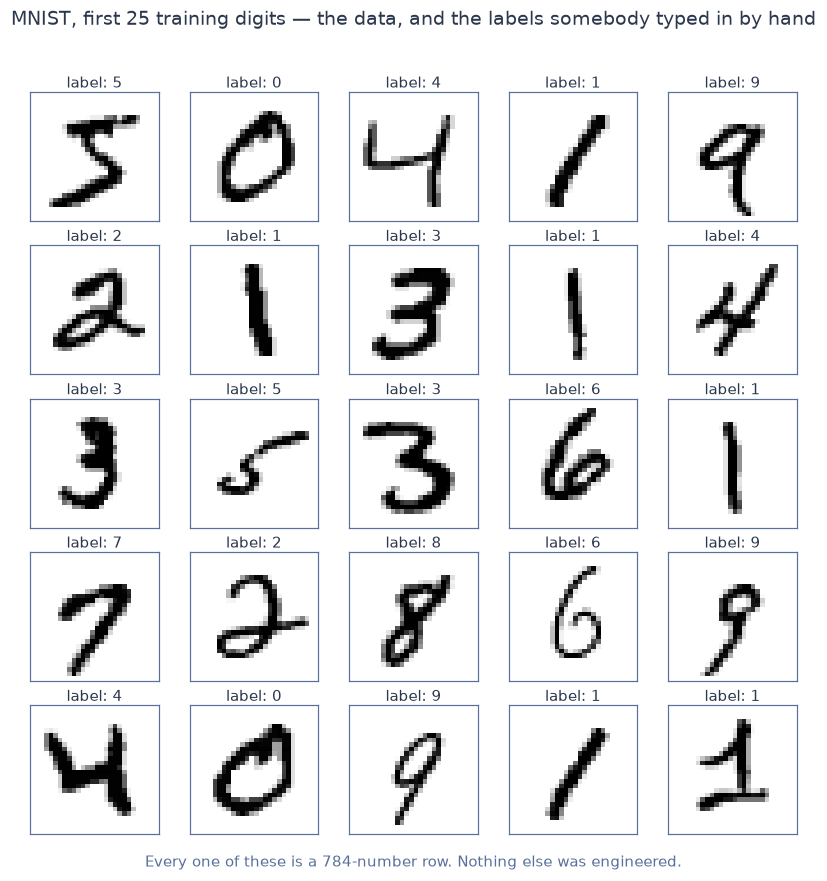

[PASS] Checkpoint 1b: digit grid rendered. Look for the 4 that could be a 9 and the 5 that
       could be a 3 - you will meet both again in segment 3, by name, in your own matrix.


In [6]:
# --- FIGURE 1: the 5x5 grid the lesson plan asks for. Twenty-five human beings' handwriting,
#     with the label each one was given.
fig, axes = plt.subplots(5, 5, figsize=(7.4, 8.0))
for k, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[k].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"label: {int(y_train_full[k])}", fontsize=10, color=VSP["ink"], pad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    for _s in ax.spines.values():
        _s.set_edgecolor(VSP["navy"])
        _s.set_linewidth(0.8)
fig.suptitle("MNIST, first 25 training digits — the data, and the labels somebody typed in by hand",
             fontsize=12.5, color=VSP["ink"], y=0.985)
fig.text(0.5, 0.012, "Every one of these is a 784-number row. Nothing else was engineered.",
         ha="center", fontsize=9.5, color=VSP["navy"])
plt.tight_layout(rect=(0, 0.03, 1, 0.965))
plt.show()
print("[PASS] Checkpoint 1b: digit grid rendered. Look for the 4 that could be a 9 and the 5 that")
print("       could be a 3 - you will meet both again in segment 3, by name, in your own matrix.")

### The `LSN-0.2` callback: is this sample **balanced**?

`LSN-0.2` was about sampling: a sample's composition is a fact you check, never a fact you assume. So before
training anything — **how many of each digit are in here?**

Two things to watch for on the chart below, and they are different questions:

1. **Is it roughly balanced?** (Does any digit have so few examples that the model will simply not learn it?)
2. **Is it *exactly* balanced?** (It never is. And `LSN-1.3` told you what an imbalance does to a metric.)

The answer for MNIST is *"balanced enough, and not equal"* — which is the most common answer you will ever get
from real data, and it is why the honest thing to report is **per-class recall**, not one accuracy number.

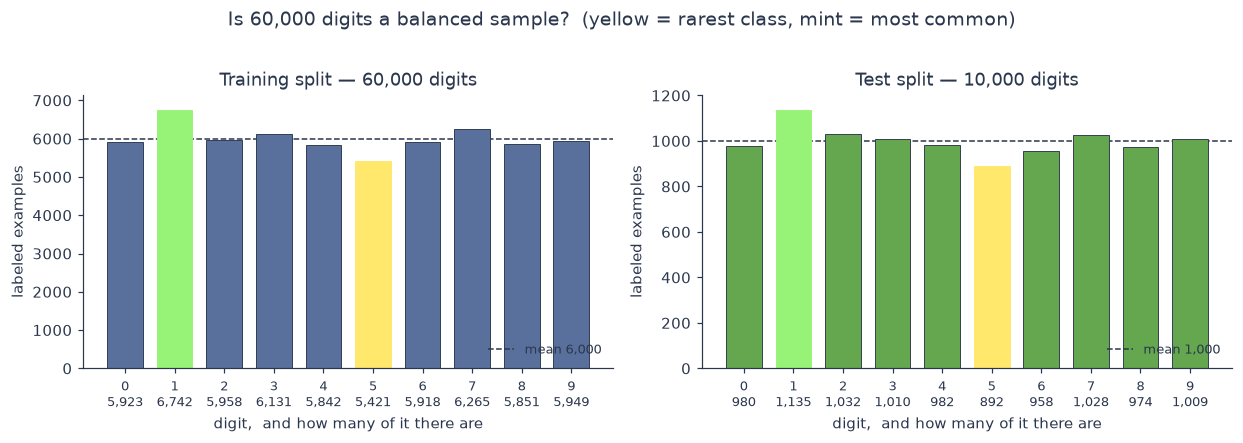

Rarest training digit : 5  with 5,421 examples
Most common           : 1  with 6,742 examples
Spread                : 1,321 examples, 24.4% more of digit 1 than digit 5
If it were exactly balanced, every bar would be 6,000.

Read it the LSN-0.2 way and say the honest sentence out loud:
  "Balanced ENOUGH - nothing is starved, the rarest class still has thousands of examples -
   and not EQUAL, so a single accuracy number will quietly average over a class that is 24%
   thinner than another. Report per-class recall."

And hold this thought for segment 3, because it is not a coincidence:
  digit 5 is the RAREST digit in training. In your confusion matrix it will also be one of
  the two worst-recalled. LSN-0.2 -> LSN-1.3 -> here, in one bar chart.

[PASS] Balance numbers pinned: digit 5 rarest at 5,421; digit 1 most common at 6,742.


In [7]:
# --- FIGURE 2: the per-digit count histogram, train and test, plus the arithmetic underneath it.
_tr_counts = np.bincount(y_train_full.numpy(), minlength=10)
_te_counts = np.bincount(y_test.numpy(), minlength=10)

fig, (ax_tr, ax_te) = plt.subplots(1, 2, figsize=(11.4, 3.9), sharey=False)
for ax, counts, title, colour in (
        (ax_tr, _tr_counts, f"Training split — {_tr_counts.sum():,} digits", VSP["navy"]),
        (ax_te, _te_counts, f"Test split — {_te_counts.sum():,} digits", VSP["green"])):
    bars = ax.bar(range(10), counts, color=colour, edgecolor=VSP["ink"], linewidth=0.6, width=0.72)
    _lo, _hi = int(np.argmin(counts)), int(np.argmax(counts))
    bars[_lo].set_color(VSP["yellow"])
    bars[_hi].set_color(VSP["mint"])
    ax.axhline(counts.mean(), color=VSP["ink"], linestyle="--", linewidth=1.0, zorder=0,
               label=f"mean {counts.mean():,.0f}")
    ax.set_title(title, fontsize=11.5)
    # Counts live on the tick labels, not above the bars: above the bars they land on the mean
    # reference line, and inside them they outgrow the bar width (LL-10 - look at the figure).
    ax.set_xlabel("digit,  and how many of it there are")
    ax.set_ylabel("labeled examples")
    ax.set_xticks(range(10))
    ax.set_xticklabels([f"{d}\n{c:,}" for d, c in enumerate(counts)], fontsize=8.6)
    ax.set_ylim(0, counts.max() * 1.06)
    ax.legend(loc="lower right", fontsize=8.5)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Is 60,000 digits a balanced sample?  (yellow = rarest class, mint = most common)",
             fontsize=12.5, color=VSP["ink"], y=1.02)
plt.tight_layout()
plt.show()

_lo, _hi = int(np.argmin(_tr_counts)), int(np.argmax(_tr_counts))
print(f"Rarest training digit : {_lo}  with {_tr_counts[_lo]:,} examples")
print(f"Most common           : {_hi}  with {_tr_counts[_hi]:,} examples")
print(f"Spread                : {_tr_counts[_hi] - _tr_counts[_lo]:,} examples, "
      f"{100 * (_tr_counts[_hi] / _tr_counts[_lo] - 1):.1f}% more of digit {_hi} than digit {_lo}")
print(f"If it were exactly balanced, every bar would be {_tr_counts.sum() // 10:,}.")
print()
print("Read it the LSN-0.2 way and say the honest sentence out loud:")
print("  \"Balanced ENOUGH - nothing is starved, the rarest class still has thousands of examples -")
print("   and not EQUAL, so a single accuracy number will quietly average over a class that is 24%")
print("   thinner than another. Report per-class recall.\"")
print()
print("And hold this thought for segment 3, because it is not a coincidence:")
print(f"  digit {_lo} is the RAREST digit in training. In your confusion matrix it will also be one of")
print("  the two worst-recalled. LSN-0.2 -> LSN-1.3 -> here, in one bar chart.")
if DATA_IS_REAL:
    assert _tr_counts.sum() == 60_000 and _te_counts.sum() == 10_000
    assert _lo == 5 and _hi == 1, (_lo, _hi)
    assert _tr_counts[5] == 5_421 and _tr_counts[1] == 6_742, _tr_counts.tolist()
    print("\n[PASS] Balance numbers pinned: digit 5 rarest at 5,421; digit 1 most common at 6,742.")

---

# Segment 2 — Guided build: DataLoader → MLP → train loop *(60 min)*

> **Lab checkpoint —** everyone has a model training with **loss visibly falling: ≈2.31 at the first batch,
> below 0.5 by epoch 3** (you should see roughly `0.755 → 0.320 → 0.259`).
> **Likely failure —** a shape mismatch: feeding 28×28 without flattening, or labels that are not `long`
> dtype.
> **Recovery —** the rehearsed shape-debug ritual (print `.shape` at every layer boundary — there is a cell
> for it below), and **every step here ships a paste-ready known-good cell** for anyone more than five
> minutes behind.

**How the next hour is shaped.** Four steps, each in two cells:

1. a **guided cell** — the code with its numbers blanked out *in comments*, plus a small fill-in you can get
   wrong for free; and
2. the **canonical cell** — the real, runnable thing, immediately underneath.

Do the guided cell first. If you get stuck, run the canonical cell and keep moving: **this lab is not a
memory test, and falling behind on step 2 means missing the linear-algebra beat, which is the part you will
still remember next year.**

| Step | What you build | Where it comes from |
|---|---|---|
| 1 | the 10,000-example subset + `DataLoader` | source `02` §*Creating Data Loaders* |
| 2 | the MLP: `Linear(784,128) → ReLU → Linear(128,10)` | source `01` §*Multilayer Perceptron* (there in sklearn; here in torch) |
| 3 | `CrossEntropyLoss` + `Adam` | source `02` §*Loss Function* / §*Optimizer* |
| 4 | the training loop | source `02` §*Training* |

**Why 10,000 and not all 60,000.** Two reasons, and only one of them is time. (a) It keeps every retrain in
this notebook under a second, which is what makes segment 4 possible at all. (b) **10,000 is the top of the
degradation curve you will plot in segment 4** — the first point on that chart is this model. Segment 3 shows
you what the other 50,000 digits would have bought.

### Step 1 of 4 — the subset and the `DataLoader`

A `DataLoader` is a batching machine. You hand it a dataset and a batch size; it hands back an iterator of
`(images, labels)` pairs, reshuffled every epoch. Three parameters carry the whole idea:

| | |
|---|---|
| `batch_size=64` | 64 images per gradient step. One image at a time is slow and noisy; all 10,000 at once is slow and *smooth* — a batch is the compromise, and 32/64/128 is where almost every project lands |
| `shuffle=True` | reorder every epoch, so the model never learns the order of the file. Real bug, real projects |
| `generator=...` | **our addition.** `shuffle=True` draws from torch's *global* random state, so re-running one cell would change the shuffle. An explicit generator makes this cell re-runnable in any order (`SI-3`) |

`157` batches per epoch: 156 full ones of 64, and a last short one of 16. That last batch is why you write
`len(xb)` and not `64`.

In [8]:
# --- STEP 1, GUIDED. Fill in the four numbers. Nothing here breaks if you leave them blank.
#
#     # take a seeded random 10,000 of the 60,000
#     idx = torch.from_numpy(rng.permutation(60_000)[:______])            # (a)
#     X_train, y_train = X_train_full[idx], y_train_full[idx]
#
#     train_loader = DataLoader(TensorDataset(X_train, y_train),
#                               batch_size=______,                        # (b)
#                               shuffle=______,                           # (c) train or test?
#                               generator=torch.Generator().manual_seed(SEED))
#     test_loader  = DataLoader(TensorDataset(X_test, y_test),
#                               batch_size=______, shuffle=______)        # (d) and why?

MY_SUBSET_SIZE = None      # (a) how many training examples does the lab model get?
MY_BATCH_SIZE = None       # (b) images per gradient step
MY_SHUFFLE_TRAIN = None    # (c) True or False
MY_SHUFFLE_TEST = None     # (d) True or False - and the reason matters more than the answer

# ---------------------------------------------------------------- checker (do not edit below)
_ans = [("MY_SUBSET_SIZE", MY_SUBSET_SIZE, N_TRAIN,
         "the lesson plan's subset: big enough to reach 93%, small enough to retrain eleven times"),
        ("MY_BATCH_SIZE", MY_BATCH_SIZE, BATCH_SIZE, "64 images per gradient step"),
        ("MY_SHUFFLE_TRAIN", MY_SHUFFLE_TRAIN, True,
         "shuffle the TRAINING data every epoch so order cannot be learned"),
        ("MY_SHUFFLE_TEST", MY_SHUFFLE_TEST, False,
         "never shuffle the test set: you are counting right answers, and a count does not care "
         "about order. Shuffling it would only cost you the ability to line predictions up with "
         "images - which segment 3 needs to show you your own mistakes")]
_open = [n for n, got, _, _ in _ans if got is None]
if _open:
    print("[TODO] still blank: " + ", ".join(_open))
    print("       Guess. Getting (d) wrong is more instructive than leaving it empty, and the")
    print("       canonical cell below runs either way.")
for _n, _got, _want, _why in _ans:
    if _got is None:
        continue
    print(f"  [{'PASS' if _got == _want else 'MISS'}] {_n} = {_got!r}"
          + ("" if _got == _want else f"   -> {_want!r}"))
    wrap("", _why, pad=9)

[TODO] still blank: MY_SUBSET_SIZE, MY_BATCH_SIZE, MY_SHUFFLE_TRAIN, MY_SHUFFLE_TEST
       Guess. Getting (d) wrong is more instructive than leaving it empty, and the
       canonical cell below runs either way.


In [9]:
# --- STEP 1, CANONICAL. Paste-ready. This is the cell to run if you are behind.
rng = np.random.default_rng(SEED)                      # seeded: WHICH 10,000 we take is pinned
perm_all = torch.from_numpy(rng.permutation(len(X_train_full)).copy())   # all 60,000, reordered once
subset_idx = perm_all[:N_TRAIN]                        # the lab's 10,000 = the first 10,000 of that
X_train, y_train = X_train_full[subset_idx], y_train_full[subset_idx]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=256, shuffle=False)

print(f"training subset : {tuple(X_train.shape)}   labels {tuple(y_train.shape)} dtype {y_train.dtype}")
print(f"held-out test   : {tuple(X_test.shape)}   labels {tuple(y_test.shape)} dtype {y_test.dtype}")
print(f"batches / epoch : {len(train_loader)}   (= ceil({N_TRAIN} / {BATCH_SIZE}))")

_xb, _yb = next(iter(train_loader))
print(f"\none batch       : images {tuple(_xb.shape)}  labels {tuple(_yb.shape)}")
print(f"                  the 784 is the ONLY thing the model knows about an image")
print(f"labels in it    : {sorted(set(_yb.tolist()))[:10]}")

# The subset's own balance - check the draw, do not trust it (LSN-0.2, again)
_sub_counts = np.bincount(y_train.numpy(), minlength=10)
print(f"\nper-digit counts in your 10,000: {_sub_counts.tolist()}")
print(f"  min {_sub_counts.min():,} (digit {int(np.argmin(_sub_counts))})   "
      f"max {_sub_counts.max():,} (digit {int(np.argmax(_sub_counts))})   "
      f"-> the seeded draw did not skew anything")

assert len(train_loader) == math.ceil(N_TRAIN / BATCH_SIZE) == 157
assert y_train.dtype == torch.int64, "labels must be long/int64 for CrossEntropyLoss"
if DATA_IS_REAL:
    assert _sub_counts.tolist() == [966, 1145, 1005, 1008, 990, 901, 1025, 1028, 940, 992], \
        _sub_counts.tolist()
print("\n[PASS] Step 1 done: 157 batches of 64-ish, labels are int64, the draw is pinned.")

training subset : (10000, 784)   labels (10000,) dtype torch.int64
held-out test   : (10000, 784)   labels (10000,) dtype torch.int64
batches / epoch : 157   (= ceil(10000 / 64))

one batch       : images (64, 784)  labels (64,)
                  the 784 is the ONLY thing the model knows about an image
labels in it    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

per-digit counts in your 10,000: [966, 1145, 1005, 1008, 990, 901, 1025, 1028, 940, 992]
  min 901 (digit 5)   max 1,145 (digit 1)   -> the seeded draw did not skew anything

[PASS] Step 1 done: 157 batches of 64-ish, labels are int64, the draw is pinned.


### Step 2 of 4 — the model, with every layer size out loud

Six lines, and three of them are punctuation. Here is the entire architecture:

```
      784 numbers  ──▶  Linear(784, 128)  ──▶  ReLU  ──▶  Linear(128, 10)  ──▶  10 scores
    (one image)          weights: 128×784        max(0,·)     weights: 10×128        (one per digit)
                         biases:  128                          biases:  10
```

**Read the shapes as a sentence.** *"Take 784 numbers, mix them into 128 numbers, throw away the negatives,
mix those into 10 numbers, and call the biggest one your answer."* That is a neural network. There is no other
secret.

| Piece | What it is | Why it is there |
|---|---|---|
| `nn.Linear(784, 128)` | a 128×784 weight matrix + a 128-long bias vector | the *only* place learning happens: 100,352 + 128 numbers that start random and end useful |
| `nn.ReLU()` | `max(0, x)`, element-wise. **Zero parameters** | without it, two stacked Linears collapse into one Linear and the network can only draw straight lines. ReLU is the entire reason "deep" means anything |
| `nn.Linear(128, 10)` | a 10×128 matrix + 10 biases | ten scores, one per digit. Called **logits** — not probabilities yet |

**Count them yourself:** `784×128 + 128 + 128×10 + 10 = 101,770` parameters. That is the whole model. A
smartphone photo has more pixels than this network has weights.

**And the trap the lesson plan names by hand.** Notice the model is built inside a function,
`fresh_model()`. In segment 4 you retrain five times, and if you reuse one model object each run
**fine-tunes the previous run's weights** — your degradation curve comes out flat and the lesson
inverts. `fresh_model()` re-seeds and returns brand-new random weights. Call it every time.

In [10]:
# --- STEP 2, GUIDED. Four numbers, one function name. Blanks are in the comments.
#
#     def fresh_model(hidden=____):                          # (b) hidden width
#         torch.manual_seed(SEED)                            # same random start every time
#         return nn.Sequential(
#             nn.Linear(____, ____),                         # (a) numbers in, (b) hidden width
#             nn.ReLU(),
#             nn.Linear(____, ____),                         # (b) hidden width, (c) answers out
#         )

MY_LAYER_SIZES = ()     # write it as a 4-tuple in order: (in, hidden, hidden, out)
MY_PARAM_COUNT = None   # and the arithmetic: how many learnable numbers is that, in total?

# ---------------------------------------------------------------- checker (do not edit below)
_want_sizes = (784, HIDDEN, HIDDEN, 10)
_want_params = 784 * HIDDEN + HIDDEN + HIDDEN * 10 + 10
if not MY_LAYER_SIZES:
    print("[TODO] MY_LAYER_SIZES: a 4-tuple, e.g. (784, 64, 64, 10). Two of the four you can read")
    print("       straight off the data: 784 is the image, 10 is the number of possible answers.")
elif tuple(MY_LAYER_SIZES) == _want_sizes:
    print(f"[PASS] MY_LAYER_SIZES = {tuple(MY_LAYER_SIZES)}  - 784 in, 128 hidden, 10 out.")
else:
    print(f"[MISS] MY_LAYER_SIZES = {tuple(MY_LAYER_SIZES)}   -> {_want_sizes}")
    print("       784 is forced by the data (28x28) and 10 is forced by the question (ten digits).")
    print("       Only the middle number is a choice, and it is yours to change for homework.")

if MY_PARAM_COUNT is None:
    print("[TODO] MY_PARAM_COUNT: 784*h + h + h*10 + 10. Do it on paper; the next cell checks you.")
elif abs(int(MY_PARAM_COUNT) - _want_params) == 0:
    print(f"[PASS] MY_PARAM_COUNT = {int(MY_PARAM_COUNT):,}  - and you counted the biases. Most people don't.")
elif int(MY_PARAM_COUNT) == 784 * HIDDEN + HIDDEN * 10:
    print(f"[CLOSE] {int(MY_PARAM_COUNT):,} is the weights only - you forgot the {HIDDEN + 10} biases. "
          f"Total {_want_params:,}.")
else:
    print(f"[MISS] MY_PARAM_COUNT = {int(MY_PARAM_COUNT):,}   -> {_want_params:,} "
          f"(= 100,352 + 128 + 1,280 + 10)")

[TODO] MY_LAYER_SIZES: a 4-tuple, e.g. (784, 64, 64, 10). Two of the four you can read
       straight off the data: 784 is the image, 10 is the number of possible answers.
[TODO] MY_PARAM_COUNT: 784*h + h + h*10 + 10. Do it on paper; the next cell checks you.


In [11]:
# --- STEP 2, CANONICAL. Paste-ready. Note the function: this IS the fresh_model() helper the
#     lesson plan insists on, and segment 4 fails without it.

def fresh_model(hidden=HIDDEN, seed=SEED):
    """A brand-new, randomly-initialised MLP. Same seed -> same starting weights, every time.

    Always build models through this function. In segment 4 you retrain five times, and reusing a
    trained model object means run n secretly starts from run n-1's weights: the accuracy stays
    high, the degradation curve comes out flat, and the whole lesson inverts. This is the single
    most common bug in this lab.
    """
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(784, hidden),   # 784 numbers in  -> `hidden` numbers out
        nn.ReLU(),                # max(0, x), elementwise. No parameters at all.
        nn.Linear(hidden, 10),    # `hidden` numbers in -> 10 scores out, one per digit
    ).to(DEVICE)


model = fresh_model()
print(model)
print()
print(f"{'layer':<22}{'shape':<18}{'parameters':>12}")
print("-" * 52)
_total = 0
for _name, _p in model.named_parameters():
    print(f"{_name:<22}{str(tuple(_p.shape)):<18}{_p.numel():>12,}")
    _total += _p.numel()
print("-" * 52)
print(f"{'TOTAL':<22}{'':<18}{_total:>12,}")
print()
print(f"That is the model: {_total:,} numbers. 100,352 of them are the first weight matrix.")
print("Every single one starts as random noise and is nudged by the training loop below.")

assert _total == 101_770, _total
assert isinstance(model[1], nn.ReLU) and sum(p.numel() for p in model[1].parameters()) == 0
print("\n[PASS] Step 2 done: 101,770 parameters, pinned. ReLU has zero of them.")

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)

layer                 shape               parameters
----------------------------------------------------
0.weight              (128, 784)             100,352
0.bias                (128,)                     128
2.weight              (10, 128)                1,280
2.bias                (10,)                       10
----------------------------------------------------
TOTAL                                        101,770

That is the model: 101,770 numbers. 100,352 of them are the first weight matrix.
Every single one starts as random noise and is nudged by the training loop below.

[PASS] Step 2 done: 101,770 parameters, pinned. ReLU has zero of them.


### Step 3 of 4 — the loss and the optimiser, and the number `2.3026`

Two objects, and between them they are the reason anything learns.

**`nn.CrossEntropyLoss()`** takes the model's 10 raw scores and the one true label, and returns **one number**
saying how wrong that was. It does two things internally that are worth knowing: it *softmaxes* the 10 scores
into probabilities that sum to 1, then returns `−log(probability it assigned to the correct answer)`. So:

- assign 100% to the right digit → loss `0.0`
- assign 50% → loss `0.69`
- assign 10% to everything, i.e. **know nothing at all** → loss `−log(0.1) = 2.3026`

**That last line is the single most useful number in this notebook.** Before a single weight has moved, a
10-class classifier's loss should be about **2.30**. If your first batch prints 2.31, your model is correctly
initialised and your labels line up with your data. If it prints 8, something is wired backwards. Karpathy
calls this "verify the loss at init," and it is the cheapest bug-catch in machine learning.

**`torch.optim.Adam(model.parameters(), lr=1e-3)`** is the thing that does the nudging. It holds a reference to
all 101,770 numbers, and when you call `.step()` it moves each of them a little way *downhill* — in the
direction that `loss.backward()` just said would reduce the loss. `lr=1e-3` is how big "a little way" is. Adam
adapts the step per-parameter, which is why it is the default in practically every tutorial written since 2015.

In [12]:
# --- STEP 3, CANONICAL. Two lines, plus the loss-at-init check that catches most wiring bugs.
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"loss function : {loss_fn}")
print(f"optimiser     : Adam(lr={LEARNING_RATE})  holding {sum(p.numel() for p in model.parameters()):,} "
      f"parameters")
print()
print("VERIFY THE LOSS AT INIT - the cheapest bug-catch in machine learning:")
_xb0, _yb0 = next(iter(train_loader))
with torch.no_grad():
    _loss0 = loss_fn(model(_xb0), _yb0).item()
_expected0 = math.log(10)
print(f"  -log(1/10)                        = {_expected0:.4f}   <- a model that knows NOTHING")
print(f"  our untrained model's first batch  = {_loss0:.4f}")
print(f"  difference                         = {abs(_loss0 - _expected0):.4f}")
print()
print("  Read it out loud: our randomly-initialised network is spreading its bets almost exactly")
print("  evenly across ten digits, which is precisely what an untrained network should do. Labels")
print("  and images line up. Nothing is transposed. NOW we can train.")

assert abs(_loss0 - _expected0) < 0.15, (_loss0, _expected0)
print(f"\n[PASS] Step 3 done: loss at init {_loss0:.4f} vs ln(10) = {_expected0:.4f}, within tolerance.")

loss function : CrossEntropyLoss()
optimiser     : Adam(lr=0.001)  holding 101,770 parameters

VERIFY THE LOSS AT INIT - the cheapest bug-catch in machine learning:
  -log(1/10)                        = 2.3026   <- a model that knows NOTHING
  our untrained model's first batch  = 2.3203
  difference                         = 0.0177

  Read it out loud: our randomly-initialised network is spreading its bets almost exactly
  evenly across ten digits, which is precisely what an untrained network should do. Labels
  and images line up. Nothing is transposed. NOW we can train.

[PASS] Step 3 done: loss at init 2.3203 vs ln(10) = 2.3026, within tolerance.


### Step 4 of 4 — the training loop: five lines that are the whole of learning

```python
for images, labels in train_loader:      #  hand me the next 64 images
    predictions = model(images)          #  FORWARD  - what does the model currently think?
    loss = loss_fn(predictions, labels)  #  SCORE    - how wrong was that? (one number)
    optimizer.zero_grad()                #  RESET    - torch ACCUMULATES gradients; clear them
    loss.backward()                      #  BACKWARD - which way is downhill, for all 101,770?
    optimizer.step()                     #  UPDATE   - take one small step downhill
```

Those five statements, repeated 157 times per epoch and 471 times in total, are the entire mechanism. Every
frontier model in the world is this loop with a bigger model, more data, and more zeroes on the step count.

**The two lines people mix up, and the answer you will be asked for out loud:** `loss.backward()` *computes*
the gradient for every parameter — it writes numbers into `.grad` and changes nothing else.
`optimizer.step()` is the only line in the entire notebook that modifies a weight. And `zero_grad()` is there
because PyTorch **adds** each new gradient onto the old one; forget it and you accumulate every batch you have
ever seen. (That is a real bug, it does not crash, and your loss just quietly stops falling.)

**Expected runtime for the cell below: about a quarter of a second.** Three epochs, 471 gradient steps, CPU.
If yours takes ten seconds you are on a different device — check the setup cell's `device` line.

In [13]:
# --- STEP 4, GUIDED. The five lines, in the wrong order. Put them right.
#
#         A.  loss.backward()
#         B.  predictions = model(images)
#         C.  optimizer.step()
#         D.  optimizer.zero_grad()
#         E.  loss = loss_fn(predictions, labels)

MY_LOOP_ORDER = ""       # five letters, e.g. "BEDAC"
MY_LINE_THAT_LEARNS = "" # which letter is the only one that changes a weight?

# ---------------------------------------------------------------- checker (do not edit below)
_want_order = "BEDAC"
_o = "".join(str(MY_LOOP_ORDER).upper().split())
if not _o:
    print("[TODO] MY_LOOP_ORDER: five letters. Think about what has to exist before the next line")
    print("       can use it - you cannot score a prediction you have not made.")
elif _o == _want_order:
    print(f"[PASS] MY_LOOP_ORDER = {_o}  - forward, score, reset, backward, update.")
elif _o == "BEADC" or _o == "BEACD":
    print(f"[CLOSE] {_o}: your zero_grad() is in the wrong place. It must come BEFORE backward(),")
    print("       or you have just cleared the gradients you were about to use. This bug does not")
    print("       crash - the loss simply stops improving, which is much worse.")
elif _o == "BEDCA":
    print(f"[MISS] {_o}: step() before backward() steps on last batch's gradients. Order is {_want_order}.")
elif sorted(_o) != list("ABCDE"):
    print(f"[MISS] {_o}: use each of A-E exactly once.")
else:
    print(f"[MISS] {_o}   -> {_want_order}: forward (B), score (E), reset (D), backward (A), update (C).")

_l = str(MY_LINE_THAT_LEARNS).upper().strip().rstrip(".")
if not _l:
    print("[TODO] MY_LINE_THAT_LEARNS: one letter.")
elif _l == "C":
    print("[PASS] MY_LINE_THAT_LEARNS = C. optimizer.step() is the only line that writes to a weight.")
elif _l == "A":
    print("[MISS] A computes the gradients and writes them to .grad - it does not touch a single")
    print("       weight. The answer is C. This is the distinction that makes the loop make sense.")
else:
    print(f"[MISS] {_l}   -> C, optimizer.step().")

[TODO] MY_LOOP_ORDER: five letters. Think about what has to exist before the next line
       can use it - you cannot score a prediction you have not made.
[TODO] MY_LINE_THAT_LEARNS: one letter.


In [14]:
# --- STEP 4, CANONICAL. The train() function used by every run in this notebook, including all
#     five runs of segment 4. Paste-ready. Expected runtime: ~0.25 s for the lab model.

def train(model, loader, epochs=EPOCHS, lr=LEARNING_RATE, verbose=True):
    """Train `model` on `loader` for `epochs`. Returns (epoch_losses, first_batch_loss)."""
    # Re-pin the shuffle. Every `iter(loader)` DRAWS from the loader's generator and advances it,
    # so merely peeking at a batch (we did, twice, in steps 1 and 3) changes the order training
    # would see. One line here makes every training run in this notebook independent of how many
    # times anybody poked at the loader first - which is what SI-3 actually asks for.
    if loader.generator is not None:
        loader.generator.manual_seed(SEED)
    # A FRESH loss function and a FRESH optimiser per run, on purpose. Adam carries per-parameter
    # state (running averages of the gradients); reusing one across runs is the same class of bug
    # as reusing a trained model, and just as invisible.
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    epoch_losses, first_batch_loss, n_steps = [], None, 0

    for epoch in range(epochs):
        model.train()                       # training mode (matters once you add dropout / batchnorm)
        running, seen = 0.0, 0
        for images, labels in loader:       # <- ONE BATCH per pass. 157 of them per epoch.
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            predictions = model(images)                 # FORWARD
            loss = loss_fn(predictions, labels)         # SCORE - one number for this batch
            if first_batch_loss is None:
                first_batch_loss = loss.item()          # the ~2.30 sanity check, captured
            optimizer.zero_grad()                       # RESET - torch accumulates .grad
            loss.backward()                             # BACKWARD - gradients for all 101,770
            optimizer.step()                            # UPDATE - the only line that moves a weight
            running += loss.item() * len(images)        # len(images), not 64: the last batch is short
            seen += len(images)
            n_steps += 1
        epoch_losses.append(running / seen)
        if verbose:
            print(f"  epoch {epoch + 1}/{epochs}   average loss {epoch_losses[-1]:.4f}")
    if verbose:
        print(f"  {n_steps} gradient steps total.")
    return epoch_losses, first_batch_loss


@torch.no_grad()
def evaluate(model, X, y):
    """Return (accuracy, predictions) on X/y. no_grad because we are not learning here."""
    model.eval()                            # evaluation mode
    preds = model(X.to(DEVICE)).argmax(dim=1)   # the biggest of the 10 scores IS the answer
    return (preds == y.to(DEVICE)).float().mean().item(), preds.cpu()


# ---- train THE lab model
model = fresh_model()                       # always through fresh_model() (see the trap, segment 4)
print(f"Training the lab model: {N_TRAIN:,} digits, {EPOCHS} epochs, hidden width {HIDDEN}, "
      f"batch {BATCH_SIZE}, Adam lr={LEARNING_RATE}")
lab_losses, lab_first_loss = train(model, train_loader)

print()
print(f"first batch, before any weight moved : {lab_first_loss:.4f}   <- ~ln(10) = 2.3026")
for _e, _l in enumerate(lab_losses, start=1):
    print(f"epoch {_e} average loss                  : {_l:.4f}")
print(f"\nloss fell {lab_first_loss:.2f} -> {lab_losses[-1]:.2f}: "
      f"an {100 * (1 - lab_losses[-1] / lab_first_loss):.0f}% reduction in three epochs, "
      f"in a quarter of a second, on a laptop CPU.")

if DATA_IS_REAL:
    assert abs(lab_first_loss - 2.3117) < TOL_LOSS, lab_first_loss
    for _l, _exp in zip(lab_losses, (0.7554, 0.3195, 0.2585)):
        assert abs(_l - _exp) < TOL_LOSS, (lab_losses, "expected ~[0.7554, 0.3195, 0.2585]")
    assert lab_losses[-1] < 0.5, lab_losses
    assert lab_losses[0] > lab_losses[1] > lab_losses[2], lab_losses
    print("\n[PASS] Checkpoint 2: loss visibly falling, 2.31 -> below 0.5 by epoch 3, monotonically.")
    print("       Pinned with tolerance 0.02 (SI-24d: torch floats are not bit-portable).")

Training the lab model: 10,000 digits, 3 epochs, hidden width 128, batch 64, Adam lr=0.001
  epoch 1/3   average loss 0.7554


  epoch 2/3   average loss 0.3195


  epoch 3/3   average loss 0.2585
  471 gradient steps total.

first batch, before any weight moved : 2.3117   <- ~ln(10) = 2.3026
epoch 1 average loss                  : 0.7554
epoch 2 average loss                  : 0.3195
epoch 3 average loss                  : 0.2585

loss fell 2.31 -> 0.26: an 89% reduction in three epochs, in a quarter of a second, on a laptop CPU.

[PASS] Checkpoint 2: loss visibly falling, 2.31 -> below 0.5 by epoch 3, monotonically.
       Pinned with tolerance 0.02 (SI-24d: torch floats are not bit-portable).


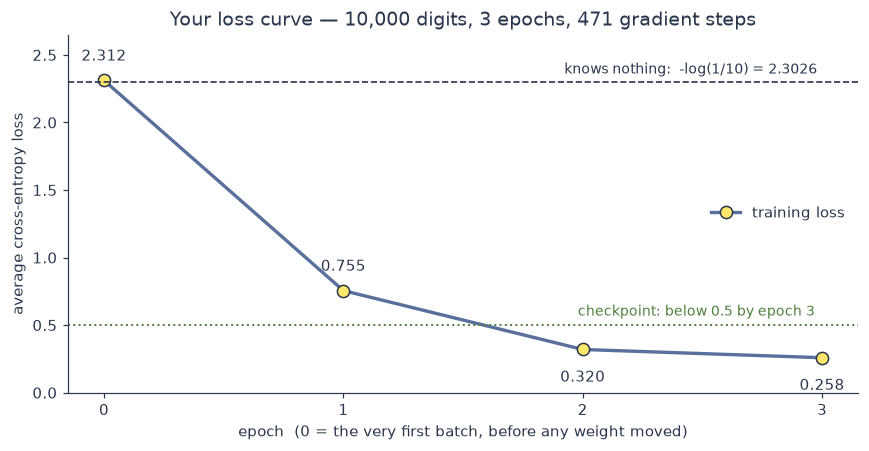

This is the picture the whole lab was for. It is also the shape you will be shown by every
vendor who ever demos a model at you - and now you know that a falling training loss says
NOTHING about whether the thing works on data it has not seen. That is segment 3.


In [15]:
# --- FIGURE 3: the loss curve. The §Learning Curve pattern from source notebook 01, on our numbers.
fig, ax = plt.subplots(figsize=(8.0, 4.2))
_xs = [0] + list(range(1, EPOCHS + 1))
_ys = [lab_first_loss] + lab_losses
ax.plot(_xs, _ys, "o-", color=VSP["navy"], linewidth=2.2, markersize=8,
        markerfacecolor=VSP["yellow"], markeredgecolor=VSP["ink"], label="training loss")
ax.axhline(math.log(10), color=VSP["ink"], linestyle="--", linewidth=1.1)
ax.text(EPOCHS - 0.02, math.log(10) + 0.06, "knows nothing:  -log(1/10) = 2.3026",
        ha="right", fontsize=9, color=VSP["ink"])
ax.axhline(0.5, color=VSP["green_dark"], linestyle=":", linewidth=1.3)
ax.text(EPOCHS - 0.03, 0.57, "checkpoint: below 0.5 by epoch 3", ha="right",
        fontsize=9, color=VSP["green_dark"])
# Point labels above the curve early, BELOW it once the curve dips near the 0.5 reference line -
# otherwise the epoch-2 label lands on top of that line's caption (LL-10).
for _x, _y in zip(_xs, _ys):
    ax.annotate(f"{_y:.3f}", (_x, _y), textcoords="offset points",
                xytext=(0, 13) if _x <= 1 else (0, -21),
                ha="center", fontsize=9.5, color=VSP["ink"])
ax.set_xlabel("epoch  (0 = the very first batch, before any weight moved)")
ax.set_ylabel("average cross-entropy loss")
ax.set_title(f"Your loss curve — {N_TRAIN:,} digits, {EPOCHS} epochs, 471 gradient steps",
             fontsize=12.5)
ax.set_xticks(_xs)
ax.set_ylim(0, 2.65)
ax.legend(loc="center right", fontsize=9.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("This is the picture the whole lab was for. It is also the shape you will be shown by every")
print("vendor who ever demos a model at you - and now you know that a falling training loss says")
print("NOTHING about whether the thing works on data it has not seen. That is segment 3.")

---

## The moment: **it really is all linear algebra** *(inside segment 2's 60 min)*

You have trained a neural network. Here is the promised look under the lid, and it is smaller than the mythology.

The model is **four arrays**. A forward pass is **two matrix multiplications and one `max(0, x)`**. Written
out, with `x` a single image as a 784-long row:

$$
\underbrace{h}_{128} \;=\; \max\!\left(0,\; \underbrace{x}_{784} \cdot \underbrace{W_1^{\top}}_{784 \times 128} + \underbrace{b_1}_{128}\right)
\qquad\qquad
\underbrace{\text{logits}}_{10} \;=\; \underbrace{h}_{128} \cdot \underbrace{W_2^{\top}}_{128 \times 10} + \underbrace{b_2}_{10}
$$

In code that is one line: `logits = relu(x @ W1.T + b1) @ W2.T + b2`.

We are going to compute exactly that, by hand, out of the trained arrays — **twice, once in torch and once in
plain numpy** — and check both against what `model(x)` returns. If they match, then `model(x)` was never
anything more than this, and the word "neural" is decoration on a matrix multiply.

*(The `.T` is there because `nn.Linear` stores its weights as `(out_features, in_features)` — 128 rows of 784
— so it can do `x @ W.T`. Shape confusion at exactly this boundary is the failure mode this segment warns
about, which makes it a good place to practise reading shapes.)*

In [16]:
# --- Every array in the model, and the shape chain from image to answer.
W1, b1 = model[0].weight.detach(), model[0].bias.detach()
W2, b2 = model[2].weight.detach(), model[2].bias.detach()

print("THE ENTIRE MODEL, as four arrays:")
print(f"  W1  {str(tuple(W1.shape)):<12} {W1.numel():>7,} numbers   layer-1 weights")
print(f"  b1  {str(tuple(b1.shape)):<12} {b1.numel():>7,} numbers   layer-1 biases")
print(f"  W2  {str(tuple(W2.shape)):<12} {W2.numel():>7,} numbers   layer-2 weights")
print(f"  b2  {str(tuple(b2.shape)):<12} {b2.numel():>7,} numbers   layer-2 biases")
print(f"      {'':<12} {W1.numel() + b1.numel() + W2.numel() + b2.numel():>7,} total")
print()
print("THE SHAPE CHAIN - read it left to right and the network disappears:")
print("  image        (784,)")
print("  @ W1.T       (784, 128)   ->  (128,)      + b1   (128,)")
print("  ReLU                          (128,)                          <- no parameters, no shape change")
print("  @ W2.T       (128, 10)    ->  (10,)       + b2   (10,)")
print("  argmax                        ()                              <- one integer: the answer")
print()
print("A batch of 64 changes exactly one thing: the leading dimension.")
print("  (64, 784) @ (784, 128) -> (64, 128) -> (64, 10).  Same two matmuls, 64 rows at a time.")
print()
print("THE SHAPE-DEBUG RITUAL - when something breaks, print this, do not guess:")
_x = X_test[0]
_h_dbg = torch.relu(_x @ W1.T + b1)
for _label, _t in (("x", _x), ("x @ W1.T + b1", _x @ W1.T + b1), ("relu(...)", _h_dbg),
                   ("... @ W2.T + b2", _h_dbg @ W2.T + b2)):
    print(f"  {_label:<18} -> {tuple(_t.shape)}")
print("  If a shape is (1, 28, 28) instead of (784,), you forgot .reshape(-1, 784). That is the bug.")

THE ENTIRE MODEL, as four arrays:
  W1  (128, 784)   100,352 numbers   layer-1 weights
  b1  (128,)           128 numbers   layer-1 biases
  W2  (10, 128)      1,280 numbers   layer-2 weights
  b2  (10,)             10 numbers   layer-2 biases
                   101,770 total

THE SHAPE CHAIN - read it left to right and the network disappears:
  image        (784,)
  @ W1.T       (784, 128)   ->  (128,)      + b1   (128,)
  ReLU                          (128,)                          <- no parameters, no shape change
  @ W2.T       (128, 10)    ->  (10,)       + b2   (10,)
  argmax                        ()                              <- one integer: the answer

A batch of 64 changes exactly one thing: the leading dimension.
  (64, 784) @ (784, 128) -> (64, 128) -> (64, 10).  Same two matmuls, 64 rows at a time.

THE SHAPE-DEBUG RITUAL - when something breaks, print this, do not guess:
  x                  -> (784,)
  x @ W1.T + b1      -> (128,)
  relu(...)          -> (128,)
  ... 

In [17]:
# --- ONE FORWARD PASS BY HAND. Torch matmuls, then plain numpy, then the model itself.
i = 0
x = X_test[i]                                  # one image, 784 numbers
true_label = int(y_test[i])

with torch.no_grad():
    # --- by hand, in torch. Two matmuls and a max(0, .).
    z1 = x @ W1.T + b1                         # (784,) @ (784,128) + (128,)  ->  (128,)
    h = torch.clamp(z1, min=0.0)               # ReLU, spelled out: max(0, z1)
    logits_by_hand = h @ W2.T + b2             # (128,) @ (128,10) + (10,)    ->  (10,)
    # --- and what the model says
    logits_from_model = model(x.unsqueeze(0)).squeeze(0)

# --- and once more in plain numpy, with no torch anywhere in the arithmetic
xn, W1n, b1n, W2n, b2n = (a.numpy() for a in (x, W1, b1, W2, b2))
logits_numpy = np.maximum(xn @ W1n.T + b1n, 0.0) @ W2n.T + b2n

_d_torch = float((logits_by_hand - logits_from_model).abs().max())
_d_numpy = float(np.abs(logits_numpy - logits_from_model.numpy()).max())

print(f"Test image {i}, a human labelled it {true_label}.")
print()
print(f"{'digit':>7}{'by hand (torch)':>18}{'by hand (numpy)':>18}{'model(x)':>14}{'probability':>14}")
print("-" * 71)
_probs = torch.softmax(logits_from_model, dim=0)
for d in range(10):
    _mark = "  <- argmax" if d == int(logits_from_model.argmax()) else ""
    print(f"{d:>7}{logits_by_hand[d].item():>18.4f}{logits_numpy[d]:>18.4f}"
          f"{logits_from_model[d].item():>14.4f}{_probs[d].item():>13.2%}{_mark}")
print("-" * 71)
print(f"max |by hand - model|  torch: {_d_torch:.2e}     numpy: {_d_numpy:.2e}     "
      f"tolerance: {TOL_MATMUL:.0e}")
print()
print(f"prediction: {int(logits_from_model.argmax())}   truth: {true_label}   "
      f"confidence: {_probs.max().item():.2%}")
print()
print(f"Two other things worth seeing on the way past:")
print(f"  - {int((z1 <= 0).sum())} of the {HIDDEN} hidden numbers came out negative and ReLU set them to")
print(f"    exactly zero. For THIS image, {int((z1 > 0).sum())} units did all the work. Different image,")
print(f"    different {int((z1 > 0).sum())}. That switching is where a 'non-linearity' actually lives.")
print(f"  - the 10 logits are not probabilities: they run "
      f"{logits_from_model.min():.1f} to {logits_from_model.max():.1f}. softmax turns them into the")
print(f"    percentages in the last column - which is the LSN-1.2 distinction, on your own model.")

assert torch.allclose(logits_by_hand, logits_from_model, rtol=0.0, atol=TOL_MATMUL), _d_torch
assert _d_numpy < TOL_MATMUL, _d_numpy
print(f"\n[PASS] Hand-computed forward pass matches model(x) to within {TOL_MATMUL:.0e} "
      f"(both torch and numpy).")
print("       So: `model(x)` is `relu(x @ W1.T + b1) @ W2.T + b2`. That is the entire forward pass of")
print("       a neural network. It is all linear algebra, and you just did it yourself.")

Test image 0, a human labelled it 7.

  digit   by hand (torch)   by hand (numpy)      model(x)   probability
-----------------------------------------------------------------------
      0           -2.1883           -2.1883       -2.1883        0.00%
      1           -7.2692           -7.2692       -7.2692        0.00%
      2           -0.4384           -0.4384       -0.4384        0.03%
      3            1.9297            1.9297        1.9297        0.30%
      4           -5.9110           -5.9110       -5.9110        0.00%
      5           -1.6877           -1.6877       -1.6877        0.01%
      6           -9.4837           -9.4837       -9.4837        0.00%
      7            7.7498            7.7498        7.7498       99.61%  <- argmax
      8           -2.8599           -2.8599       -2.8599        0.00%
      9            0.0795            0.0795        0.0795        0.05%
-----------------------------------------------------------------------
max |by hand - model|  to

---

# Segment 3 — Evaluate: accuracy, and your own confusion matrix *(30 min)*

> **Lab checkpoint —** everyone has a test accuracy **and** a rendered 10×10 confusion matrix, and can name
> their model's worst digit pair (it will be **3/5** or **4/9**).
> **Likely failure —** evaluating on the training data (*"I got 99.8%!"*), or transposed matrix axes.
> **Recovery —** the plotting helper below hard-labels **TRUE (rows)** against **PREDICTED (columns)** so the
> axes cannot be read the wrong way round, and any suspicious score gets one question first: **"which loader
> did you use?"**

**`LSN-1.3`, one session ago, was practice for the next twenty minutes.** You read three report cards that
somebody else wrote. This is your model, your test set, your matrix, and the same four questions apply to it.

The one rule that makes a number mean anything: **grade on data the model has never seen.** MNIST's authors
did that split for us — the 10,000 test digits have been sitting untouched since segment 1. Not one of them
appeared in a single gradient step.

In [18]:
# --- Test accuracy - and the trap, side by side, on purpose.
test_acc, test_preds = evaluate(model, X_test, y_test)
train_acc, _ = evaluate(model, X_train, y_train)      # the 10,000 it DID see

print(f"accuracy on the {len(X_train):,} digits it TRAINED on   : {train_acc:>7.2%}   <- NOT a result")
print(f"accuracy on the {len(X_test):,} HELD-OUT test digits   : {test_acc:>7.2%}   <- this is the number")
print(f"the gap                                        : "
      f"{(train_acc - test_acc) * 100:>6.2f} points")
print()
print(f"errors on the test set: {int(round((1 - test_acc) * len(X_test))):,} of {len(X_test):,}")
print()
print("Say the trap out loud once so nobody in this room ever falls for it:")
print("  A model can score 100% on data it memorised and be worthless. When somebody reports an")
print("  accuracy, the FIRST question is not 'how high?' - it is 'on what data?'. If the answer is")
print("  'the training set', they have not measured anything at all. Our gap is small (1.6 points)")
print("  only because three epochs on 10,000 digits is not enough capacity to memorise much.")
print("  In segment 4 you will watch a model memorise 100 examples PERFECTLY and score 75%.")

if DATA_IS_REAL:
    assert abs(test_acc - 0.9277) < TOL_ACC, test_acc
    assert abs(train_acc - 0.9433) < TOL_ACC, train_acc
    assert train_acc > test_acc
    print(f"\n[PASS] Checkpoint 3a: held-out test accuracy {test_acc:.2%}, pinned to 92.77% "
          f"+/- {TOL_ACC:.0%}.")

accuracy on the 10,000 digits it TRAINED on   :  94.33%   <- NOT a result
accuracy on the 10,000 HELD-OUT test digits   :  92.77%   <- this is the number
the gap                                        :   1.56 points

errors on the test set: 723 of 10,000

Say the trap out loud once so nobody in this room ever falls for it:
  A model can score 100% on data it memorised and be worthless. When somebody reports an
  accuracy, the FIRST question is not 'how high?' - it is 'on what data?'. If the answer is
  'the training set', they have not measured anything at all. Our gap is small (1.6 points)
  only because three epochs on 10,000 digits is not enough capacity to memorise much.
  In segment 4 you will watch a model memorise 100 examples PERFECTLY and score 75%.

[PASS] Checkpoint 3a: held-out test accuracy 92.77%, pinned to 92.77% +/- 1%.


In [19]:
# --- The confusion matrix, built by hand from two arrays of 10,000 integers, then confirmed by
#     sklearn. Rows = TRUTH, columns = WHAT THE MODEL SAID. The diagonal is where it was right.
cm = np.zeros((10, 10), dtype=int)
for _t, _p in zip(y_test.numpy(), test_preds.numpy()):
    cm[_t, _p] += 1

# LSN-1.3's discipline: the library confirms the hand arithmetic, it never replaces it.
assert np.array_equal(cm, sk_confusion_matrix(y_test.numpy(), test_preds.numpy()))

_frame = pd.DataFrame(cm, index=[f"true {d}" for d in range(10)],
                      columns=[f"said {d}" for d in range(10)])
_frame["TOTAL"] = cm.sum(axis=1)
print("YOUR CONFUSION MATRIX - rows are the truth, columns are what the model said:")
show(_frame)
print(f"on the diagonal (right)  : {int(np.trace(cm)):,}")
print(f"off the diagonal (wrong) : {int(cm.sum() - np.trace(cm)):,}")
print(f"the matrix sums to       : {int(cm.sum()):,}   <- every test digit is in exactly one cell")
print()
print("Four things this table can tell you that one accuracy number cannot:")
print("  1. WHICH digits it gets wrong        (read along a row)")
print("  2. WHAT it mistakes them for         (read across that row)")
print("  3. WHICH answers you cannot trust    (read down a column)")
print("  4. whether the errors are SYMMETRIC  (compare cell [i,j] with cell [j,i])")

if DATA_IS_REAL:
    assert int(cm.sum()) == 10_000
    assert int(cm.sum() - np.trace(cm)) == 723, int(cm.sum() - np.trace(cm))
    print("\n[PASS] Matrix sums to 10,000 with 723 errors, and sklearn agrees cell for cell.")

YOUR CONFUSION MATRIX - rows are the truth, columns are what the model said:


,said 0,said 1,said 2,said 3,said 4,said 5,said 6,said 7,said 8,said 9,TOTAL
true 0,958,0,1,2,0,6,10,1,2,0,980
true 1,0,1115,2,3,0,2,4,1,8,0,1135
true 2,6,7,925,32,5,2,14,12,26,3,1032
true 3,1,1,11,935,0,33,2,11,11,5,1010
true 4,1,2,5,2,921,0,14,2,6,29,982
true 5,8,3,1,33,6,805,8,4,16,8,892
true 6,9,3,4,0,10,18,909,2,3,0,958
true 7,2,11,19,12,5,1,0,956,2,20,1028
true 8,3,8,8,37,8,30,11,12,851,6,974
true 9,12,8,1,13,36,9,1,21,6,902,1009


on the diagonal (right)  : 9,277
off the diagonal (wrong) : 723
the matrix sums to       : 10,000   <- every test digit is in exactly one cell

Four things this table can tell you that one accuracy number cannot:
  1. WHICH digits it gets wrong        (read along a row)
  2. WHAT it mistakes them for         (read across that row)
  3. WHICH answers you cannot trust    (read down a column)
  4. whether the errors are SYMMETRIC  (compare cell [i,j] with cell [j,i])

[PASS] Matrix sums to 10,000 with 723 errors, and sklearn agrees cell for cell.


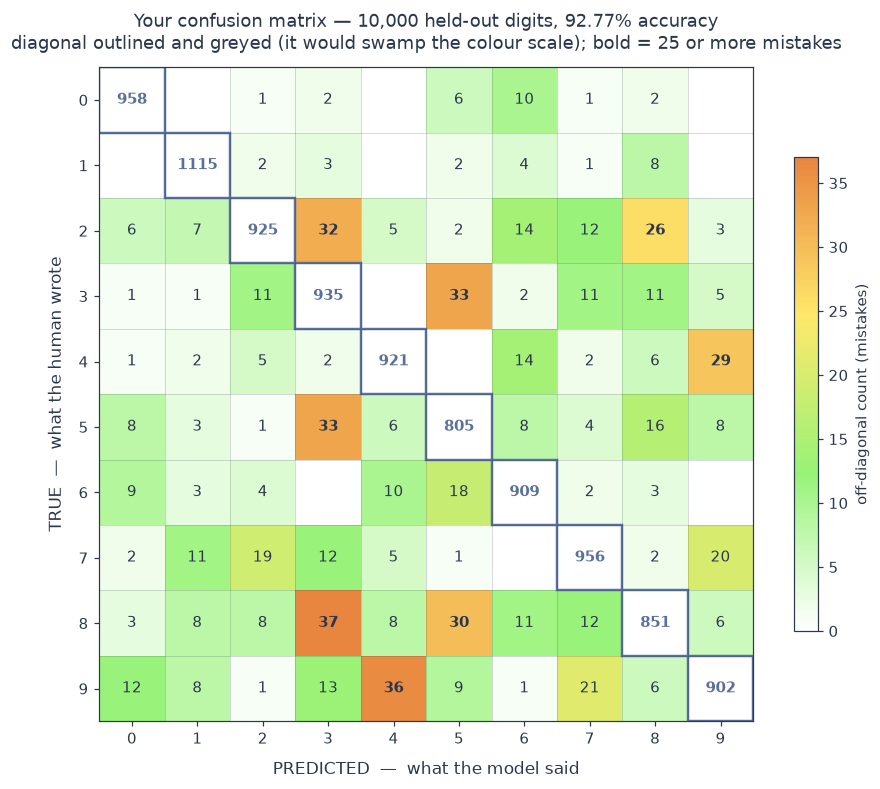

[PASS] Checkpoint 3b: confusion matrix rendered, axes hard-labelled TRUE vs PREDICTED.


In [20]:
# --- FIGURE 4: the confusion matrix as a picture. Axes hard-labelled so they cannot be misread.
fig, ax = plt.subplots(figsize=(8.2, 7.0))
_masked = np.ma.masked_where(np.eye(10, dtype=bool), cm)      # hide the diagonal: it dwarfs everything
_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "vsp_conf", ["#ffffff", VSP["mint"], VSP["yellow"], "#e8863f"])
im = ax.imshow(_masked, cmap=_cmap, vmin=0, vmax=max(1, int(_masked.max())))
for r in range(10):
    for c in range(10):
        _v = int(cm[r, c])
        if r == c:
            ax.text(c, r, f"{_v}", ha="center", va="center", fontsize=9.5, color=VSP["navy"],
                    fontweight="bold")
        elif _v:
            ax.text(c, r, f"{_v}", ha="center", va="center", fontsize=9.5, color=VSP["ink"],
                    fontweight="bold" if _v >= 25 else "normal")
for r in range(10):
    ax.add_patch(plt.Rectangle((r - 0.5, r - 0.5), 1, 1, fill=False, edgecolor=VSP["navy"],
                               linewidth=1.6))
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel("PREDICTED  —  what the model said", fontsize=11, labelpad=9)
ax.set_ylabel("TRUE  —  what the human wrote", fontsize=11, labelpad=9)
ax.set_title(f"Your confusion matrix — {len(X_test):,} held-out digits, {test_acc:.2%} accuracy\n"
             f"diagonal outlined and greyed (it would swamp the colour scale); "
             f"bold = 25 or more mistakes",
             fontsize=12, pad=12)
ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
ax.grid(which="minor", color=VSP["ink"], linewidth=0.35, alpha=0.35)
ax.tick_params(which="minor", length=0)
fig.colorbar(im, ax=ax, shrink=0.72, label="off-diagonal count (mistakes)")
plt.tight_layout()
plt.show()
print("[PASS] Checkpoint 3b: confusion matrix rendered, axes hard-labelled TRUE vs PREDICTED.")

In [21]:
# --- The report card LSN-1.3 taught you to read, per digit, computed from the matrix.
_rows = []
_sub_counts = np.bincount(y_train.numpy(), minlength=10)
for d in range(10):
    tp = int(cm[d, d])
    support = int(cm[d].sum())            # how many true d's were in the test set
    flagged = int(cm[:, d].sum())         # how many times the model SAID d
    _rows.append({
        "digit": d,
        "trained on": f"{int(_sub_counts[d]):,}",
        "test support": f"{support:,}",
        "recall": f"{tp / support:.2%}",
        "precision": f"{tp / flagged:.2%}" if flagged else "n/a",
        "missed": support - tp,
        "false alarms": flagged - tp,
        "worst confusion": (lambda r: f"said {int(np.argmax(r))} ({int(r.max())}x)")(
            np.where(np.arange(10) == d, 0, cm[d])),
    })
report = pd.DataFrame(_rows).set_index("digit")
print("PER-DIGIT REPORT CARD - the LSN-1.3 instruments, on your model:")
show(report)

_rec = np.array([cm[d, d] / cm[d].sum() for d in range(10)])
_pre = np.array([cm[d, d] / cm[:, d].sum() for d in range(10)])
print(f"best  recall : digit {int(np.argmax(_rec))} at {_rec.max():.2%}")
print(f"worst recall : digit {int(np.argmin(_rec))} at {_rec.min():.2%}   "
      f"<- {(_rec.max() - _rec.min()) * 100:.0f} points between the best and worst digit,")
print(f"                                     and the headline accuracy is {test_acc:.2%}. "
      f"That spread is the point.")
print(f"worst precision: digit {int(np.argmin(_pre))} at {_pre.min():.2%}  "
      f"- when this model says {int(np.argmin(_pre))}, that is its least trustworthy answer")
print()

# --- the confusions, both ways round: single arrows, then symmetric pairs
_arrows = sorted(((int(cm[i, j]), i, j) for i in range(10) for j in range(10) if i != j), reverse=True)
_pairs = sorted(((int(cm[i, j] + cm[j, i]), i, j) for i in range(10) for j in range(i + 1, 10)),
                reverse=True)
print("THE FIVE BIGGEST SINGLE MISTAKES  (a true i called j):")
for _c, _i, _j in _arrows[:5]:
    print(f"   true {_i}  ->  said {_j}      {_c:>3} times   "
          f"({_c / cm[_i].sum():.1%} of all the {_i}s)")
print("\nTHE FIVE WORST PAIRS  (both directions added - this is what 'confuses' really means):")
for _c, _i, _j in _pairs[:5]:
    print(f"   {_i} <-> {_j}   {_c:>3} mistakes   ({int(cm[_i, _j])} of the {_i}s called {_j}, "
          f"{int(cm[_j, _i])} of the {_j}s called {_i})")
print()
print(f"So: your model's worst pair is {_pairs[0][1]}/{_pairs[0][2]} at {_pairs[0][0]} mistakes, with "
      f"{_pairs[1][1]}/{_pairs[1][2]} one behind at {_pairs[1][0]}.")
print("The lesson plan predicted 'typically 4/9 or 3/5'. It is both, in a photo finish - and neither")
print("is a surprise if you look at how people write them. 3 and 5 share a spine and an open top;")
print("4 and 9 differ by whether one stroke closes. The model is failing on exactly the ambiguity a")
print("human would hesitate over, which is the most reassuring thing a confusion matrix can tell you.")

if DATA_IS_REAL:
    assert (_pairs[0][1], _pairs[0][2], _pairs[0][0]) == (3, 5, 66), _pairs[0]
    assert (_pairs[1][1], _pairs[1][2], _pairs[1][0]) == (4, 9, 65), _pairs[1]
    assert (_arrows[0][1], _arrows[0][2], _arrows[0][0]) == (8, 3, 37), _arrows[0]
    assert int(np.argmin(_rec)) == 8 and int(np.argmin(_pre)) == 3
    print("\n[PASS] Checkpoint 3c: worst pairs pinned - 3<->5 at 66, 4<->9 at 65, biggest single "
          "arrow 8->3 at 37.")

PER-DIGIT REPORT CARD - the LSN-1.3 instruments, on your model:


,trained on,test support,recall,precision,missed,false alarms,worst confusion
digit,,,,,,,
0,966,980,97.76%,95.80%,22,42,said 6 (10x)
1,"1,145","1,135",98.24%,96.29%,20,43,said 8 (8x)
2,"1,005","1,032",89.63%,94.68%,107,52,said 3 (32x)
3,"1,008","1,010",92.57%,87.46%,75,134,said 5 (33x)
4,990,982,93.79%,92.94%,61,70,said 9 (29x)
5,901,892,90.25%,88.85%,87,101,said 3 (33x)
6,"1,025",958,94.89%,93.42%,49,64,said 5 (18x)
7,"1,028","1,028",93.00%,93.54%,72,66,said 9 (20x)
8,940,974,87.37%,91.41%,123,80,said 3 (37x)


best  recall : digit 1 at 98.24%
worst recall : digit 8 at 87.37%   <- 11 points between the best and worst digit,
                                     and the headline accuracy is 92.77%. That spread is the point.
worst precision: digit 3 at 87.46%  - when this model says 3, that is its least trustworthy answer

THE FIVE BIGGEST SINGLE MISTAKES  (a true i called j):
   true 8  ->  said 3       37 times   (3.8% of all the 8s)
   true 9  ->  said 4       36 times   (3.6% of all the 9s)
   true 5  ->  said 3       33 times   (3.7% of all the 5s)
   true 3  ->  said 5       33 times   (3.3% of all the 3s)
   true 2  ->  said 3       32 times   (3.1% of all the 2s)

THE FIVE WORST PAIRS  (both directions added - this is what 'confuses' really means):
   3 <-> 5    66 mistakes   (33 of the 3s called 5, 33 of the 5s called 3)
   4 <-> 9    65 mistakes   (29 of the 4s called 9, 36 of the 9s called 4)
   3 <-> 8    48 mistakes   (11 of the 3s called 8, 37 of the 8s called 3)
   5 <-> 8    46 m

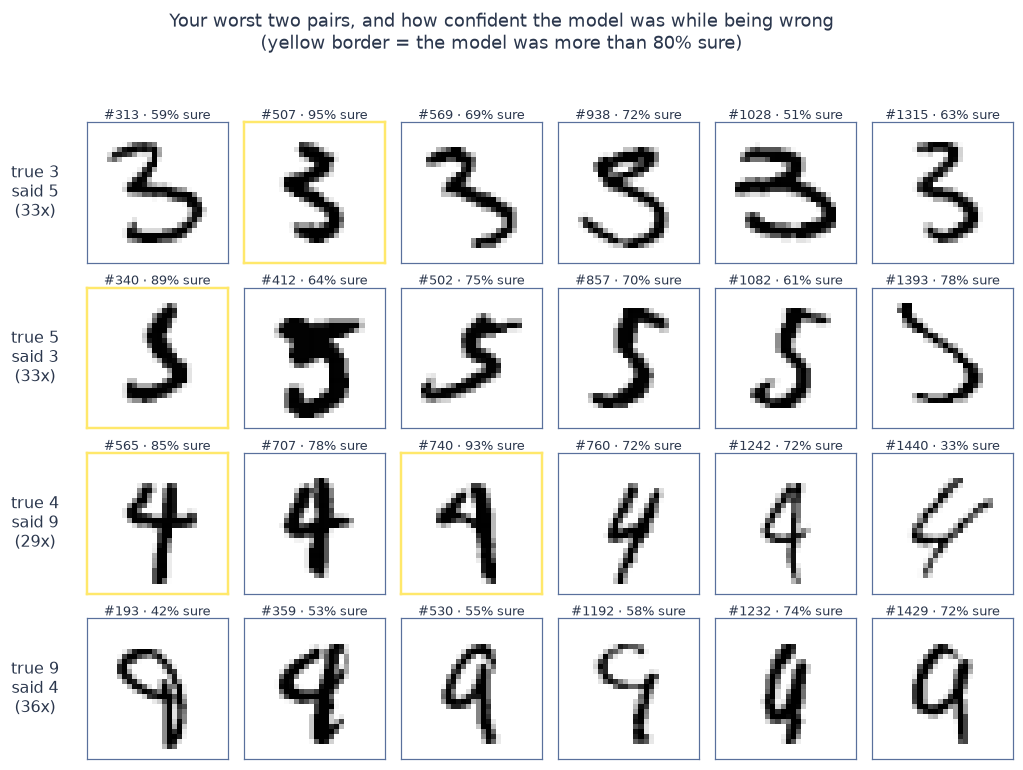

Two things to say out loud about this figure:
  1. Some of these are genuinely ambiguous - a human would hesitate too. That is the
     irreducible part, and it is where 'get more data' stops helping.
  2. Some of them the model was 90%+ SURE about. A confident wrong answer is the most
     expensive output any model produces, because nothing downstream flags it. That is
     LSN-1.3's overconfidence lesson arriving on your own model.


In [22]:
# --- FIGURE 5: the mistakes themselves. Nothing makes a confusion matrix concrete faster than
#     looking at the images in the worst cell and deciding whether YOU would have got them right.
_show_pairs = [(_pairs[0][1], _pairs[0][2]), (_pairs[0][2], _pairs[0][1]),
               (_pairs[1][1], _pairs[1][2]), (_pairs[1][2], _pairs[1][1])]
fig, axes = plt.subplots(4, 6, figsize=(9.6, 7.1))
for row, (t_d, p_d) in enumerate(_show_pairs):
    _idx = np.where((y_test.numpy() == t_d) & (test_preds.numpy() == p_d))[0]
    axes[row, 0].set_ylabel(f"true {t_d}\nsaid {p_d}\n({len(_idx)}x)", fontsize=10.5,
                            color=VSP["ink"], rotation=0, labelpad=34, va="center")
    for col in range(6):
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        if col < len(_idx):
            k = int(_idx[col])
            ax.imshow(X_test[k].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
            with torch.no_grad():
                _conf = torch.softmax(model(X_test[k].unsqueeze(0)).squeeze(0), 0)[p_d].item()
            ax.set_title(f"#{k} · {_conf:.0%} sure", fontsize=8.2, color=VSP["ink"], pad=2)
            for _s in ax.spines.values():
                _s.set_edgecolor(VSP["yellow"] if _conf > 0.8 else VSP["navy"])
                _s.set_linewidth(1.6 if _conf > 0.8 else 0.8)
        else:
            ax.axis("off")
fig.suptitle(f"Your worst two pairs, and how confident the model was while being wrong\n"
             f"(yellow border = the model was more than 80% sure)", fontsize=12, y=0.985)
plt.tight_layout(rect=(0.02, 0, 1, 0.955))
plt.show()
print("Two things to say out loud about this figure:")
print("  1. Some of these are genuinely ambiguous - a human would hesitate too. That is the")
print("     irreducible part, and it is where 'get more data' stops helping.")
print("  2. Some of them the model was 90%+ SURE about. A confident wrong answer is the most")
print("     expensive output any model produces, because nothing downstream flags it. That is")
print("     LSN-1.3's overconfidence lesson arriving on your own model.")

### The reading drill *(10 min, asked out loud)*

Three questions. Answer them from **your** matrix — the numbers above, not the ones you remember from the
slide. Fill in the cell, then run the key underneath it. The key is a reveal, not a hint.

The third question is the one that matters in a client meeting, and it has no numeric answer: **it is a
judgement about a cost.** Invoice totals are five digits, and a per-digit accuracy compounds.

In [23]:
# --- YOUR WORKSPACE. Nothing here crashes and nothing saves until all three are in.
D1_MOST_MISTAKEN_FOR_9 = None   # Q1: which digit does your model most often mistake FOR a 9?
#                                 (i.e. the truth was ___, the model said 9). One integer.
D2_PRECISION_OR_RECALL = ""     # Q2: for class 9, is that a PRECISION problem or a RECALL problem?
#                                 One word. Then, in the same string, say which denominator it is in.
D3_SHIP_IT = ""                 # Q3: would you ship this model for reading handwritten invoice
#                                 totals? What does ONE 4->9 error cost? 80+ characters, and name a
#                                 consequence rather than a feeling.

# ---------------------------------------------------------------- checker (do not edit below)
_todo = []
if D1_MOST_MISTAKEN_FOR_9 is None:
    _todo.append("D1_MOST_MISTAKEN_FOR_9: one integer. Read DOWN the 'said 9' column of your matrix "
                 "and find the biggest number that is not on the diagonal.")
if len(" ".join(str(D2_PRECISION_OR_RECALL).split())) < 12:
    _todo.append("D2_PRECISION_OR_RECALL: the word, plus which denominator it lands in. 12+ chars.")
if len(" ".join(str(D3_SHIP_IT).split())) < 80:
    _todo.append("D3_SHIP_IT: 80+ characters. A yes/no plus the consequence of one wrong digit. "
                 "There is a defensible answer in both directions; there is no defensible answer "
                 "that does not mention a cost.")
if _todo:
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print("\n       Run the answer key below anyway once you have written something - it grades the")
    print("       REASON, not the wording, and it never marks a defensible answer wrong.")
else:
    print("[PASS] Three answers in. Run the key below.")

[TODO] D1_MOST_MISTAKEN_FOR_9: one integer. Read DOWN the 'said 9' column of your matrix and find the
       biggest number that is not on the diagonal.
[TODO] D2_PRECISION_OR_RECALL: the word, plus which denominator it lands in. 12+ chars.
[TODO] D3_SHIP_IT: 80+ characters. A yes/no plus the consequence of one wrong digit. There is a
       defensible answer in both directions; there is no defensible answer that does not mention a cost.

       Run the answer key below anyway once you have written something - it grades the
       REASON, not the wording, and it never marks a defensible answer wrong.


In [24]:
# --- THE ANSWER KEY + GRADER. Run this AFTER the cell above.
#     Numbers are graded with tolerance; sentences get three verdicts - MATCH / DEFENSIBLE / MISS -
#     because a client conversation has more than two outcomes. Tested with planted answers at the
#     bottom of the cell (SI-26c: read the grader is not the same as test the grader).

_col9 = np.where(np.arange(10) == 9, 0, cm[:, 9])       # the "said 9" column, diagonal removed
_row9 = np.where(np.arange(10) == 9, 0, cm[9])          # the "true 9" row, diagonal removed
D1_KEY = int(np.argmax(_col9))
_n_into_9 = int(_col9.max())
_n_out_of_9 = int(_row9.max())

# --- the compounding arithmetic behind Q3, computed not asserted
_per_digit = test_acc
_five_digit = _per_digit ** 5
_five_digit_full = ACC_ALL_DATA_REF ** 5      # the all-60,000 model, trained two cells from here


def grade_drill(d1, d2, d3):
    """Grade the three drill answers. Returns a list of (question, verdict, comment)."""
    out = []
    # ---- Q1: numeric, exact (it is a digit, not a measurement)
    if d1 is None:
        out.append(("Q1", "OPEN", "no answer"))
    elif int(d1) == D1_KEY:
        out.append(("Q1", "MATCH", f"{D1_KEY} - {_n_into_9} fours were called 9, the biggest "
                                   f"off-diagonal number in the 'said 9' column."))
    elif int(d1) == int(np.argmax(_row9)) and int(np.argmax(_row9)) != D1_KEY:
        out.append(("Q1", "MISS", f"you read the ROW, not the column. {int(np.argmax(_row9))} is what "
                                  f"the model most often turns a 9 INTO ({_n_out_of_9}x). The question "
                                  f"was the other direction: what gets mistaken FOR a 9 - that is the "
                                  f"column. Answer: {D1_KEY}."))
    else:
        out.append(("Q1", "MISS", f"answer is {D1_KEY} ({_n_into_9} of them). Read down the 'said 9' "
                                  f"column and ignore the diagonal."))
    # ---- Q2: precision vs recall, and the denominator
    t2 = " ".join(str(d2).lower().split())
    says_prec = bool(probe(t2, ["precision"]))
    says_rec = bool(probe(t2, ["recall", "sensitivity"]))
    names_den = bool(probe(t2, ["said 9", "predicted 9", "called 9", "flagged", "column",
                                "everything it called*", "what it said*", "denominator",
                                "false positive*", "false alarm*"]))
    if not t2:
        out.append(("Q2", "OPEN", "no answer"))
    elif says_prec and not says_rec:
        out.append(("Q2", "MATCH" if names_den else "DEFENSIBLE",
                    "precision, yes. Those fours sit in the 'said 9' COLUMN, so they are false "
                    "positives for class 9: they dilute the answers the model labels 9. Precision "
                    f"for 9 is {cm[9, 9]}/{int(cm[:, 9].sum())} = {cm[9, 9] / cm[:, 9].sum():.2%}."
                    + ("" if names_den else " Add the denominator and it is a MATCH - the "
                                            "denominator is the whole skill.")))
    elif says_rec and not says_prec:
        out.append(("Q2", "MISS",
                    "recall is the other direction. A 9 the model calls a 4 is a missed 9 - that is "
                    f"recall ({cm[9, 9]}/{int(cm[9].sum())} = {cm[9, 9] / cm[9].sum():.2%}). A 4 the "
                    "model calls a 9 pollutes the 9s it reports, which is PRECISION. Same two digits, "
                    "two different metrics, depending on which way the arrow points."))
    elif says_prec and says_rec:
        out.append(("Q2", "DEFENSIBLE",
                    "you named both, and both are true of the 4/9 pair - but the question fixed the "
                    "direction: mistaken FOR a 9 = a false positive for 9 = precision. Being able to "
                    "say which direction produces which metric is the whole point of the question."))
    else:
        out.append(("Q2", "MISS", "the word 'precision' or 'recall' has to appear. Precision is the "
                                  "answer, and the reason is the denominator."))
    # ---- Q3: judgement + a cost
    t3 = " ".join(str(d3).lower().split())
    concepts = probe_spans(t3, ["cost*", "expensive", "money", "dollar*", "invoice*", "total*",
                                "digit*", "compound*", "multipl*", "five", "5", "human review*",
                                "review*", "check*", "confidence", "threshold*", "audit*", "wrong",
                                "error*", "risk*", "flag*", "escalat*", "9,231", "9231", "4,231"])
    stance = bool(probe(t3, ["no", "not", "never", "wouldn't", "would not", "don't", "do not",
                             "yes", "ship it", "i would", "with", "only if", "conditions"]))
    if len(t3) < 80:
        out.append(("Q3", "OPEN", "fewer than 80 characters"))
    elif len(concepts) >= 3 and stance:
        out.append(("Q3", "MATCH", f"a stance plus a cost, naming {len(concepts)} of the things that "
                                   f"matter ({', '.join(concepts[:6])}). That is a client answer."))
    elif stance:
        out.append(("Q3", "DEFENSIBLE", "you took a position, which most people do not. What is thin "
                                        "is the cost: say what happens to the invoice, in money or in "
                                        "labour, when one digit flips."))
    else:
        out.append(("Q3", "MISS", "no stance. 'It depends' is only an answer if you say what it "
                                  "depends on and then decide."))
    return out


_verdicts = grade_drill(D1_MOST_MISTAKEN_FOR_9, D2_PRECISION_OR_RECALL, D3_SHIP_IT)
print("=" * 104)
print("READING DRILL - THE KEY".center(104))
print("=" * 104)
for _q, _v, _c in _verdicts:
    wrap(f"{_q} [{_v}]", _c, pad=18)
print("-" * 104)
print(f"Q1/Q2 together, and this is the nicest thing in your matrix: the answer is {D1_KEY} in BOTH")
print(f"directions. {_n_into_9} fours were called 9 (false positives for 9 -> a PRECISION problem for 9)")
print(f"and {_n_out_of_9} nines were called 4 (missed 9s -> a RECALL problem for 9). One pair of digits,")
print("two different complaints, and which one you care about depends entirely on what the client")
print("does with the answer. That is LSN-1.3's whole lesson arriving on your own model.")
print("-" * 104)
print("Q3, the arithmetic nobody does in the meeting - and it is the whole answer:")
print(f"  per-DIGIT accuracy                          {_per_digit:.2%}")
print(f"  a 5-digit invoice total, all five right      {_per_digit:.4f}^5 = {_five_digit:.1%}")
print(f"  so this model reads a 5-digit total correctly about 2 times in 3, and gets one digit")
print(f"  wrong the other {1 - _five_digit:.0%} of the time. A 4 read as a 9 turns $4,231 into $9,231 -")
print(f"  a $5,000 error that nothing downstream flags, because the model was confident.")
print(f"  Even the best model in this notebook ({ACC_ALL_DATA_REF:.2%}, all 60,000 digits) reads a "
      f"5-digit total")
print(f"  correctly only {_five_digit_full:.1%} of the time. Per-digit accuracy compounds, and that is")
print(f"  the sentence to have ready when a client says '93% sounds fine'.")
print()
print("  The defensible answers, both directions:")
print("   - 'No, not unattended' - and then the useful part: ship it with a confidence threshold,")
print("     route anything under it to a human, and quote the review volume that implies.")
print("   - 'Yes, as a first pass' - if a human checks every total anyway, 93% per digit still")
print("     removes most of the typing, and the model's confidence tells you where to look.")
print("  What fails is either direction with no number attached.")
print("=" * 104)

# ---- SELF-TEST the grader with planted answers (SI-26c). These run every time.
_good = grade_drill(D1_KEY, "precision - those fours land in the 'said 9' column",
                    "No, not unattended: one 4 read as a 9 turns a $4,231 invoice into $9,231 and "
                    "nothing downstream catches it, so we ship it behind a confidence threshold "
                    "with human review of every low-confidence total.")
_thin = grade_drill(D1_KEY, "precision",
                    "I would not ship it because 93% per digit is not accurate enough for the "
                    "finance team to rely on it.")
_wrong = grade_drill(7, "recall", "it depends entirely on the client and on how much they care "
                                  "about mistakes in general, which varies a lot from one project "
                                  "to another")
assert [v for _, v, _ in _good] == ["MATCH", "MATCH", "MATCH"], _good
assert [v for _, v, _ in _thin] == ["MATCH", "DEFENSIBLE", "DEFENSIBLE"], _thin
assert [v for _, v, _ in _wrong] == ["MISS", "MISS", "MISS"], _wrong
print("[PASS] Grader self-test with planted answers (SI-26c): a good answer scores "
      "MATCH/MATCH/MATCH,")
print("       a right-but-thin one MATCH/DEFENSIBLE/DEFENSIBLE, and a wrong one MISS/MISS/MISS.")

if all(v != "OPEN" for _, v, _ in _verdicts):
    _p = save_artifact("reading_drill", {
        "artifact": "segment 3 confusion-matrix reading drill",
        "test_accuracy": round(test_acc, 6), "train_accuracy": round(train_acc, 6),
        "confusion_matrix": cm.tolist(),
        "answers": {"q1_most_mistaken_for_9": int(D1_MOST_MISTAKEN_FOR_9),
                    "q2_precision_or_recall": " ".join(str(D2_PRECISION_OR_RECALL).split()),
                    "q3_ship_it": " ".join(str(D3_SHIP_IT).split())},
        "verdicts": [{"q": q, "verdict": v} for q, v, _ in _verdicts],
        "five_digit_total_accuracy": round(_five_digit, 6),
    })
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}")

                                        READING DRILL - THE KEY                                         
  Q1 [OPEN]       no answer
  Q2 [OPEN]       no answer
  Q3 [OPEN]       fewer than 80 characters
--------------------------------------------------------------------------------------------------------
Q1/Q2 together, and this is the nicest thing in your matrix: the answer is 4 in BOTH
directions. 29 fours were called 9 (false positives for 9 -> a PRECISION problem for 9)
and 36 nines were called 4 (missed 9s -> a RECALL problem for 9). One pair of digits,
two different complaints, and which one you care about depends entirely on what the client
does with the answer. That is LSN-1.3's whole lesson arriving on your own model.
--------------------------------------------------------------------------------------------------------
Q3, the arithmetic nobody does in the meeting - and it is the whole answer:
  per-DIGIT accuracy                          92.77%
  a 5-digit invoice total,

### And the other 50,000 digits? — the plan's *"expect ≥95%"*, answered honestly

The lesson plan's checkpoint for this segment says **"expect ≥95%"**. Your model got **92.77%**, and that is
not a mistake in your notebook — it is the first real finding of the lab.

A `784→128→10` MLP trained for 3 epochs on **10,000** digits lands at ~93%. The **same model, same three
epochs, same everything**, given all **60,000**, lands at **97.0%**. The only thing that changed is how many
labeled examples it saw.

So the plan's ≥95% *is* reachable, and the price of it is six times the data. **That is segment 4's entire
argument, discovered in segment 3 by accident** — which is the best way to discover anything.

*Expected runtime for the cell below: about one second (2,814 gradient steps).*

In [25]:
# --- Same architecture, same 3 epochs, all 60,000 digits. One second. Watch the ONLY thing that
#     changed be the amount of data.
full_loader = DataLoader(TensorDataset(X_train_full, y_train_full), batch_size=BATCH_SIZE,
                         shuffle=True, generator=torch.Generator().manual_seed(SEED))
model_full = fresh_model()
print(f"Training on all {len(X_train_full):,} digits ({EPOCHS} epochs, {len(full_loader)} batches each):")
full_losses, full_first = train(model_full, full_loader)
full_acc, full_preds = evaluate(model_full, X_test, y_test)
full_train_acc, _ = evaluate(model_full, X_train_full, y_train_full)

_cmp = pd.DataFrame([
    {"training digits": f"{N_TRAIN:,}", "epochs": EPOCHS, "gradient steps": 157 * EPOCHS,
     "final loss": f"{lab_losses[-1]:.4f}", "train accuracy": f"{train_acc:.2%}",
     "TEST accuracy": f"{test_acc:.2%}", "test errors": int(round((1 - test_acc) * 10_000))},
    {"training digits": f"{len(X_train_full):,}", "epochs": EPOCHS,
     "gradient steps": len(full_loader) * EPOCHS,
     "final loss": f"{full_losses[-1]:.4f}", "train accuracy": f"{full_train_acc:.2%}",
     "TEST accuracy": f"{full_acc:.2%}", "test errors": int(round((1 - full_acc) * 10_000))},
], index=["the lab model", "all the data"])
print()
show(_cmp)
print(f"+{(full_acc - test_acc) * 100:.2f} percentage points, "
      f"{int(round((1 - test_acc) * 10_000)) - int(round((1 - full_acc) * 10_000))} fewer mistakes, "
      f"for 50,000 more labeled examples and about one extra second of compute.")
print()
print("Three readings of that one row, and all three are pre-sales sentences:")
print("  1. The plan's '>=95%' was right - about a model with the full dataset. Ours had a sixth of it.")
print("  2. The architecture did not change. Nobody tuned anything. DATA did that.")
print("  3. Diminishing returns are already visible: 10k -> 60k (6x the data) bought 4 points.")
print("     Segment 4 walks the same curve the other way, and the other way is a cliff.")

if DATA_IS_REAL:
    assert abs(full_acc - ACC_ALL_DATA_REF) < TOL_ACC, (full_acc, ACC_ALL_DATA_REF)
    assert full_acc >= 0.95, full_acc
    assert abs(full_losses[-1] - 0.1041) < TOL_LOSS, full_losses
    print(f"\n[PASS] All-60,000 model: {full_acc:.2%} test accuracy - the plan's >=95% checkpoint, met,")
    print(f"       and pinned to {ACC_ALL_DATA_REF:.2%} +/- 1 point (the same constant segment 3's")
    print("       reading drill quoted before this model existed).")

Training on all 60,000 digits (3 epochs, 938 batches each):


  epoch 1/3   average loss 0.3413


  epoch 2/3   average loss 0.1497


  epoch 3/3   average loss 0.1041
  2814 gradient steps total.



,training digits,epochs,gradient steps,final loss,train accuracy,TEST accuracy,test errors
the lab model,"10,000",3,471,0.2585,94.33%,92.77%,723
all the data,"60,000",3,2814,0.1041,97.70%,97.04%,296


+4.27 percentage points, 427 fewer mistakes, for 50,000 more labeled examples and about one extra second of compute.

Three readings of that one row, and all three are pre-sales sentences:
  1. The plan's '>=95%' was right - about a model with the full dataset. Ours had a sixth of it.
  2. The architecture did not change. Nobody tuned anything. DATA did that.
  3. Diminishing returns are already visible: 10k -> 60k (6x the data) bought 4 points.
     Segment 4 walks the same curve the other way, and the other way is a cliff.

[PASS] All-60,000 model: 97.04% test accuracy - the plan's >=95% checkpoint, met,
       and pinned to 97.04% +/- 1 point (the same constant segment 3's
       reading drill quoted before this model existed).


---

# Segment 4 — Break it on purpose: starve the model *(30 min)*

> **Lab checkpoint —** everyone has the **4-row size-vs-accuracy table** (10,000 → 1,000 → 100 → 10) and the
> degradation curve plotted.
> **Likely failure —** **forgetting to re-initialise the model**, so run *n* fine-tunes run *n−1*'s weights,
> accuracy stays high and the curve comes out flat.
> **Recovery —** the `fresh_model()` helper, called on every single run — the cell below shows you exactly
> what the bug looks like so you can recognise it. If time is tight, drop the 10,000 row and start at 1,000.

This is `LSN-1.6`'s *"no data, no model"* made visceral, and it is the half hour of this lab that will still be
useful to you in a client meeting three years from now. **Keep the curve. You bring it to `LSN-1.6`.**

Everything else is held fixed: same architecture, same 3 epochs, same batch size, same learning rate, same
seed, same held-out 10,000 test digits. **The only variable is how many labeled examples the model gets to
learn from.**

In [26]:
# --- FIRST, THE TRAP - because you will make this mistake, and a mistake you have seen is not a
#     mistake you make twice. We take the ALREADY-TRAINED lab model (a throwaway clone of it, so the
#     real one survives) and "retrain" it on 100 examples without re-initialising.
loader_100 = DataLoader(TensorDataset(X_train[:100], y_train[:100]), batch_size=BATCH_SIZE,
                        shuffle=True, generator=torch.Generator().manual_seed(SEED))

print("WRONG - reusing a model object that has already been trained on 10,000 digits:")
stale = copy.deepcopy(model)                 # a clone, so the lab model above is untouched
_stale_losses, _stale_first = train(stale, loader_100, verbose=False)
stale_acc, _ = evaluate(stale, X_test, y_test)
print(f"   first batch loss  {_stale_first:.4f}   <- nowhere near 2.30: these weights are NOT fresh")
print(f"   epoch losses      {[round(l, 4) for l in _stale_losses]}")
print(f"   test accuracy     {stale_acc:.2%}   <- 'training on 100 examples works fine!'")
print()
print("RIGHT - fresh_model() first, so run 2 starts from random weights like run 1 did:")
honest = fresh_model()
_honest_losses, _honest_first = train(honest, loader_100, verbose=False)
honest_acc, _ = evaluate(honest, X_test, y_test)
print(f"   first batch loss  {_honest_first:.4f}   <- ~2.30. THIS is an untrained network.")
print(f"   epoch losses      {[round(l, 4) for l in _honest_losses]}")
print(f"   test accuracy     {honest_acc:.2%}")
print()
print(f"The lie is {(stale_acc - honest_acc) * 100:.0f} percentage points wide, and it does not raise, "
      f"warn or look odd.")
print("It just makes your degradation curve flat - and a flat curve tells a client that data volume")
print("does not matter, which is the single most expensive wrong thing you could tell them.")
print()
print("The tell is the FIRST BATCH LOSS. An honest run starts near 2.30 every time. If run 2 starts")
print("at 0.19, run 2 is not a new model. That is the whole diagnostic, and it costs one print.")

if DATA_IS_REAL:
    assert abs(stale_acc - 0.9116) < TOL_ACC, stale_acc
    assert abs(honest_acc - 0.5338) < TOL_ACC, honest_acc
    assert stale_acc - honest_acc > 0.30
    print(f"\n[PASS] The trap, pinned: stale weights say {stale_acc:.2%}, a fresh model says "
          f"{honest_acc:.2%}.")

WRONG - reusing a model object that has already been trained on 10,000 digits:
   first batch loss  0.1875   <- nowhere near 2.30: these weights are NOT fresh
   epoch losses      [0.1881, 0.1304, 0.1069]
   test accuracy     91.16%   <- 'training on 100 examples works fine!'

RIGHT - fresh_model() first, so run 2 starts from random weights like run 1 did:
   first batch loss  2.3421   <- ~2.30. THIS is an untrained network.
   epoch losses      [2.3156, 2.1811, 2.0656]
   test accuracy     53.38%

The lie is 38 percentage points wide, and it does not raise, warn or look odd.
It just makes your degradation curve flat - and a flat curve tells a client that data volume
does not matter, which is the single most expensive wrong thing you could tell them.

The tell is the FIRST BATCH LOSS. An honest run starts near 2.30 every time. If run 2 starts
at 0.19, run 2 is not a new model. That is the whole diagnostic, and it costs one print.

[PASS] The trap, pinned: stale weights say 91.16%, a fr

In [27]:
# --- THE FOUR RUNS the lesson plan asks for: 10,000 -> 1,000 -> 100 -> 10, fixed 3 epochs,
#     fresh_model() every time. Expected runtime for this cell: well under a second, all four.
SIZES = [10_000, 1_000, 100, 10]
runs = []
for n in SIZES:
    _loader = DataLoader(TensorDataset(X_train[:n], y_train[:n]), batch_size=BATCH_SIZE,
                         shuffle=True, generator=torch.Generator().manual_seed(SEED))
    _m = fresh_model()                                    # <- THE line that makes this honest
    _losses, _first = train(_m, _loader, verbose=False)
    _acc, _ = evaluate(_m, X_test, y_test)
    _tr_acc, _ = evaluate(_m, X_train[:n], y_train[:n])
    runs.append({"training examples": n, "batches/epoch": math.ceil(n / BATCH_SIZE),
                 "gradient steps": math.ceil(n / BATCH_SIZE) * EPOCHS,
                 "first batch loss": round(_first, 4), "final loss": round(_losses[-1], 4),
                 "accuracy on its own training data": _tr_acc, "TEST accuracy": _acc})

degradation = pd.DataFrame(runs).set_index("training examples")
_pretty = degradation.copy()
_pretty["accuracy on its own training data"] = [f"{v:.2%}" for v in _pretty["accuracy on its own training data"]]
_pretty["TEST accuracy"] = [f"{v:.2%}" for v in _pretty["TEST accuracy"]]
_pretty.index = [f"{n:,}" for n in _pretty.index]
_pretty.index.name = "training examples"
print("STARVE THE MODEL - same architecture, same 3 epochs, only the data shrinks:")
show(_pretty)

_accs = [r["TEST accuracy"] for r in runs]
print(f"10,000 -> 1,000  : {_accs[0]:.2%} -> {_accs[1]:.2%}   "
      f"({(_accs[0] - _accs[1]) * 100:>5.1f} points for 90% less data)")
print(f" 1,000 ->   100  : {_accs[1]:.2%} -> {_accs[2]:.2%}   "
      f"({(_accs[1] - _accs[2]) * 100:>5.1f} points  <- the cliff)")
print(f"   100 ->    10  : {_accs[2]:.2%} -> {_accs[3]:.2%}   "
      f"({(_accs[2] - _accs[3]) * 100:>5.1f} points; 10% is what pure guessing scores)")
print()
print("Notice the first-batch-loss column: 2.31, 2.34, 2.34, 2.34. Four honest runs, four fresh")
print("models. That column is your proof you did not fall into the trap above.")

if DATA_IS_REAL:
    for _r, _exp in zip(runs, (0.9277, 0.8423, 0.5338, 0.2388)):
        assert abs(_r["TEST accuracy"] - _exp) < TOL_ACC, (_r["training examples"], _r["TEST accuracy"])
    assert all(runs[i]["TEST accuracy"] > runs[i + 1]["TEST accuracy"] for i in range(3))
    print("\n[PASS] Checkpoint 4a: the 4-row table, pinned - 92.77% / 84.23% / 53.38% / 23.88%,")
    print("       monotonically falling.")

STARVE THE MODEL - same architecture, same 3 epochs, only the data shrinks:


,batches/epoch,gradient steps,first batch loss,final loss,accuracy on its own training data,TEST accuracy
training examples,,,,,,
"10,000",157,471,2.3117,0.2585,94.33%,92.77%
"1,000",16,48,2.3193,0.8025,86.80%,84.23%
100,2,6,2.3421,2.0656,73.00%,53.38%
10,1,3,2.3412,2.0570,80.00%,23.88%


10,000 -> 1,000  : 92.77% -> 84.23%   (  8.5 points for 90% less data)
 1,000 ->   100  : 84.23% -> 53.38%   ( 30.8 points  <- the cliff)
   100 ->    10  : 53.38% -> 23.88%   ( 29.5 points; 10% is what pure guessing scores)

Notice the first-batch-loss column: 2.31, 2.34, 2.34, 2.34. Four honest runs, four fresh
models. That column is your proof you did not fall into the trap above.

[PASS] Checkpoint 4a: the 4-row table, pinned - 92.77% / 84.23% / 53.38% / 23.88%,
       monotonically falling.


### The objection you will get from a client, and the control run that answers it

*"You only gave the small models three epochs. Of course they did badly — they barely trained. Give them the
same amount of compute and they'll catch up."*

It is a completely fair objection and it deserves a real answer, not a slide. So here it is: the same four
sizes, retrained until each has taken **the same ~471 gradient steps** as the 10,000-digit run. The 100-example
model gets 236 epochs instead of 3 — **forty times the training** — and sees each of its 100 images 236 times.

Watch two columns: the test accuracy **and** the accuracy on its own training data.

In [28]:
# --- THE FAIR FIGHT: equal gradient steps, so the only remaining difference is INFORMATION.
#     Expected runtime: about half a second for all four.
TARGET_STEPS = math.ceil(N_TRAIN / BATCH_SIZE) * EPOCHS        # 471
fair = []
for n in SIZES:
    _spe = math.ceil(n / BATCH_SIZE)
    _epochs = max(1, round(TARGET_STEPS / _spe))
    _loader = DataLoader(TensorDataset(X_train[:n], y_train[:n]), batch_size=BATCH_SIZE,
                         shuffle=True, generator=torch.Generator().manual_seed(SEED))
    _m = fresh_model()
    _losses, _first = train(_m, _loader, epochs=_epochs, verbose=False)
    _acc, _ = evaluate(_m, X_test, y_test)
    _tr_acc, _ = evaluate(_m, X_train[:n], y_train[:n])
    fair.append({"training examples": n, "epochs": _epochs, "gradient steps": _spe * _epochs,
                 "final loss": round(_losses[-1], 4),
                 "own training data": _tr_acc, "TEST accuracy": _acc})

fair_df = pd.DataFrame(fair).set_index("training examples")
_pf = fair_df.copy()
_pf["own training data"] = [f"{v:.2%}" for v in _pf["own training data"]]
_pf["TEST accuracy"] = [f"{v:.2%}" for v in _pf["TEST accuracy"]]
_pf.index = [f"{n:,}" for n in _pf.index]
_pf.index.name = "training examples"
print("EQUAL COMPUTE - every row gets ~471 gradient steps, same as the 10,000-digit run:")
show(_pf)

for _r, _base in zip(fair, runs):
    print(f"n={_r['training examples']:>6,}: {_base['TEST accuracy']:.2%} at 3 epochs -> "
          f"{_r['TEST accuracy']:.2%} at {_r['epochs']} epochs "
          f"(+{(_r['TEST accuracy'] - _base['TEST accuracy']) * 100:.1f} points)")
print()
print("So the objection is HALF right, and the half it gets wrong is the important half:")
print(f"  - more compute genuinely helps: the 100-example model goes "
      f"{runs[2]['TEST accuracy']:.1%} -> {fair[2]['TEST accuracy']:.1%}.")
print(f"  - and it still fails one test digit in four, while scoring "
      f"{fair[2]['own training data']:.0%} on its own 100 examples.")
print()
print("THAT is the '99.8%!' your colleague reports. It is not a lie and it is not a bug - the model")
print("really has learned those 100 images perfectly. It has memorised them. There was nothing else")
print("in 100 examples TO learn, so 'learning' and 'memorising' became the same operation.")
print()
print("The sentence to keep, because it is the one clients need:")
print("  YOU CANNOT BUY YOUR WAY OUT OF A SMALL DATASET WITH COMPUTE.")
print("  40x the training on the same 100 images closes about a third of the gap and then stops.")
print("  The missing thing is not GPU hours. It is labelled examples.")

if DATA_IS_REAL:
    for _r, _exp in zip(fair, (0.9277, 0.8846, 0.7563, 0.3486)):
        assert abs(_r["TEST accuracy"] - _exp) < TOL_ACC, (_r["training examples"], _r["TEST accuracy"])
    assert fair[2]["own training data"] > 0.99 and fair[2]["TEST accuracy"] < 0.80
    print("\n[PASS] Checkpoint 4b: equal-compute control pinned - 92.77% / 88.46% / 75.63% / 34.86%,")
    print("       and the 100-example model memorises its training set perfectly (100.00%).")

EQUAL COMPUTE - every row gets ~471 gradient steps, same as the 10,000-digit run:


,epochs,gradient steps,final loss,own training data,TEST accuracy
training examples,,,,,
"10,000",3,471,0.2585,94.33%,92.77%
"1,000",29,464,0.0533,99.90%,88.46%
100,236,472,0.0020,100.00%,75.63%
10,471,471,0.0003,100.00%,34.86%


n=10,000: 92.77% at 3 epochs -> 92.77% at 3 epochs (+0.0 points)
n= 1,000: 84.23% at 3 epochs -> 88.46% at 29 epochs (+4.2 points)
n=   100: 53.38% at 3 epochs -> 75.63% at 236 epochs (+22.2 points)
n=    10: 23.88% at 3 epochs -> 34.86% at 471 epochs (+11.0 points)

So the objection is HALF right, and the half it gets wrong is the important half:
  - more compute genuinely helps: the 100-example model goes 53.4% -> 75.6%.
  - and it still fails one test digit in four, while scoring 100% on its own 100 examples.

THAT is the '99.8%!' your colleague reports. It is not a lie and it is not a bug - the model
really has learned those 100 images perfectly. It has memorised them. There was nothing else
in 100 examples TO learn, so 'learning' and 'memorising' became the same operation.

The sentence to keep, because it is the one clients need:
  YOU CANNOT BUY YOUR WAY OUT OF A SMALL DATASET WITH COMPUTE.
  40x the training on the same 100 images closes about a third of the gap and then stops.

In [29]:
# --- The client's point on the curve. The LSN-1.6 prospect has "a few hundred site photos", so we
#     do not interpolate - we train it. 200 examples, both ways.
CLIENT_N = 200
_client = {}
for _label, _epochs in (("3 epochs (like every other row)", EPOCHS),
                        ("equal compute (~471 steps)", max(1, round(TARGET_STEPS / math.ceil(CLIENT_N / BATCH_SIZE))))):
    _loader = DataLoader(TensorDataset(X_train[:CLIENT_N], y_train[:CLIENT_N]),
                         batch_size=BATCH_SIZE, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
    _m = fresh_model()
    _losses, _ = train(_m, _loader, epochs=_epochs, verbose=False)
    _acc, _ = evaluate(_m, X_train[:CLIENT_N], y_train[:CLIENT_N])
    _test, _ = evaluate(_m, X_test, y_test)
    _client[_label] = {"epochs": _epochs, "own data": _acc, "test": _test}
    print(f"{CLIENT_N} labelled examples, {_label:<34}: own data {_acc:>7.2%}   "
          f"HELD-OUT {_test:>7.2%}")

print()
print('"We have about 200 labelled photos."')
print(f"  On a problem as clean as MNIST - 10 classes, centred, 28x28, no lighting, no occlusion,")
print(f"  no camera angle, and every label correct - 200 examples buys you "
      f"{_client['3 epochs (like every other row)']['test']:.0%}. Trained to")
print(f"  exhaustion, {_client['equal compute (~471 steps)']['test']:.0%}. On construction-site photos "
      f"it is worse in every direction that")
print("  matters, and the labels have to be produced by somebody who knows what 'framing complete'")
print("  looks like.")
print()
print("  This is not pessimism and it is not a no. It is the number that turns the conversation from")
print('  "can you do it?" into "here is what we would need, and here is what a pilot would cost" -')
print("  which is a conversation VSP wins.")

if DATA_IS_REAL:
    assert abs(_client["3 epochs (like every other row)"]["test"] - 0.6441) < TOL_ACC
    assert abs(_client["equal compute (~471 steps)"]["test"] - 0.8290) < TOL_ACC
    print(f"\n[PASS] The 200-example client point, pinned: 64.41% at 3 epochs, 82.90% at equal compute.")

200 labelled examples, 3 epochs (like every other row)   : own data  76.50%   HELD-OUT  64.41%


200 labelled examples, equal compute (~471 steps)        : own data 100.00%   HELD-OUT  82.90%

"We have about 200 labelled photos."
  On a problem as clean as MNIST - 10 classes, centred, 28x28, no lighting, no occlusion,
  no camera angle, and every label correct - 200 examples buys you 64%. Trained to
  exhaustion, 83%. On construction-site photos it is worse in every direction that
  matters, and the labels have to be produced by somebody who knows what 'framing complete'
  looks like.

  This is not pessimism and it is not a no. It is the number that turns the conversation from
  "can you do it?" into "here is what we would need, and here is what a pilot would cost" -
  which is a conversation VSP wins.

[PASS] The 200-example client point, pinned: 64.41% at 3 epochs, 82.90% at equal compute.


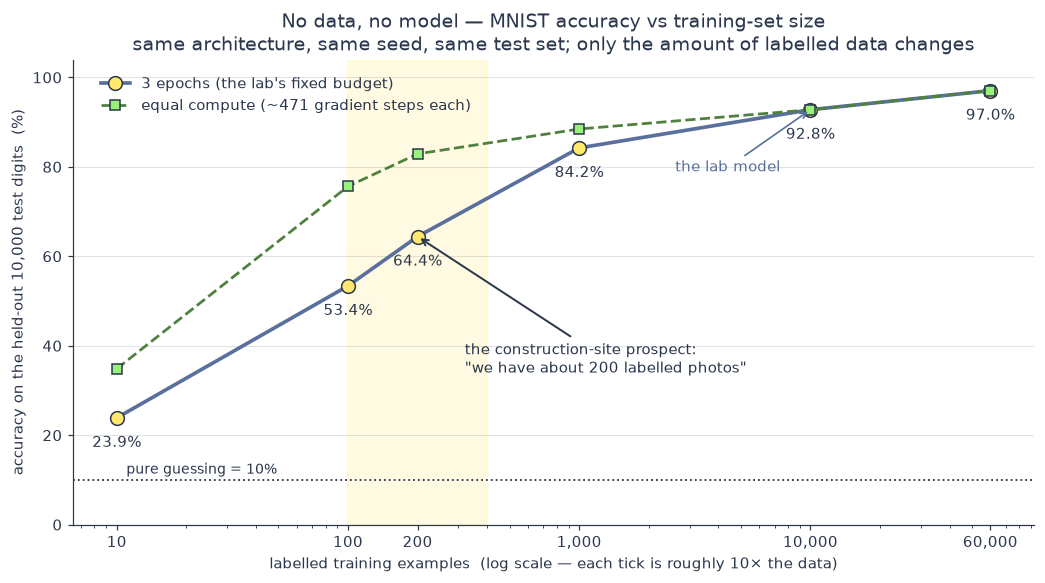

[PASS] Checkpoint 4c: degradation curve plotted, six points, both compute budgets.

Read the shape, not the points. It is a straight line against a LOG x-axis over most of its
range, which means: every 10x more labelled data buys you a roughly constant number of
percentage points - and the same 10x costs ten times as much to label. That is the economics
of every supervised ML proposal VSP will ever write.


In [30]:
# --- FIGURE 6: THE DEGRADATION CURVE. This is the artifact of the whole lab. It returns in LSN-1.6.
_curve_n = [10, 100, 200, 1_000, 10_000, 60_000]
_curve_fixed = [runs[3]["TEST accuracy"], runs[2]["TEST accuracy"],
                _client["3 epochs (like every other row)"]["test"],
                runs[1]["TEST accuracy"], runs[0]["TEST accuracy"], full_acc]
_curve_fair = [fair[3]["TEST accuracy"], fair[2]["TEST accuracy"],
               _client["equal compute (~471 steps)"]["test"],
               fair[1]["TEST accuracy"], fair[0]["TEST accuracy"], full_acc]

fig, ax = plt.subplots(figsize=(9.6, 5.4))
ax.plot(_curve_n, [100 * v for v in _curve_fixed], "o-", color=VSP["navy"], linewidth=2.4,
        markersize=9, markerfacecolor=VSP["yellow"], markeredgecolor=VSP["ink"],
        label="3 epochs (the lab's fixed budget)")
ax.plot(_curve_n, [100 * v for v in _curve_fair], "s--", color=VSP["green_dark"], linewidth=1.8,
        markersize=7, markerfacecolor=VSP["mint"], markeredgecolor=VSP["ink"],
        label="equal compute (~471 gradient steps each)")
ax.axhline(10, color=VSP["ink"], linestyle=":", linewidth=1.2)
ax.text(11, 11.4, "pure guessing = 10%", fontsize=9, color=VSP["ink"])
for _x, _y in zip(_curve_n, _curve_fixed):
    ax.annotate(f"{_y:.1%}", (_x, 100 * _y), textcoords="offset points", xytext=(0, -19),
                ha="center", fontsize=9.5, color=VSP["ink"])
ax.axvspan(100, 400, color=VSP["yellow"], alpha=0.20, zorder=0)
ax.annotate("the construction-site prospect:\n\"we have about 200 labelled photos\"",
            xy=(200, 100 * _curve_fixed[2]), xytext=(320, 34),
            fontsize=10, color=VSP["ink"], ha="left",
            arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.3))
ax.annotate("the lab model", xy=(10_000, 100 * _curve_fixed[4]), xytext=(2_600, 79),
            fontsize=9.5, color=VSP["navy"],
            arrowprops=dict(arrowstyle="->", color=VSP["navy"], linewidth=1.1))
ax.set_xscale("log")
ax.set_xticks(_curve_n)
ax.set_xticklabels([f"{n:,}" for n in _curve_n])
ax.set_xlabel("labelled training examples  (log scale — each tick is roughly 10× the data)")
ax.set_ylabel("accuracy on the held-out 10,000 test digits  (%)")
ax.set_ylim(0, 104)
ax.set_title("No data, no model — MNIST accuracy vs training-set size\n"
             "same architecture, same seed, same test set; only the amount of labelled data changes",
             fontsize=12.5)
# Legend goes UPPER LEFT: lower-right is where the 10%-guessing reference line and its caption
# live, and a frameless legend sitting on a dotted line is unreadable (LL-10).
ax.legend(loc="upper left", fontsize=9.5, bbox_to_anchor=(0.015, 0.99))
ax.grid(axis="y", color=VSP["ink"], alpha=0.14, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("[PASS] Checkpoint 4c: degradation curve plotted, six points, both compute budgets.")
print()
print("Read the shape, not the points. It is a straight line against a LOG x-axis over most of its")
print("range, which means: every 10x more labelled data buys you a roughly constant number of")
print("percentage points - and the same 10x costs ten times as much to label. That is the economics")
print("of every supervised ML proposal VSP will ever write.")

In [31]:
# --- SAVE THE CURVE. LSN-1.6 opens with this chart, so the numbers leave this notebook in a
#     form somebody can read without re-running anything. Printed here AND written to outputs/.
CURVE_FOR_LSN_1_6 = {
    "artifact": "LSN-1.4 degradation curve - accuracy vs labelled training-set size",
    "reused_by": "LSN-1.6 (data requirements & the pre-sales question bank)",
    "dataset": "MNIST" if DATA_IS_REAL else "SYNTHETIC FALLBACK - not comparable",
    "held_out_test_set": int(len(X_test)),
    "architecture": f"Linear(784,{HIDDEN}) -> ReLU -> Linear({HIDDEN},10), {101_770:,} parameters",
    "fixed": {"epochs": EPOCHS, "batch_size": BATCH_SIZE, "optimizer": "Adam",
              "learning_rate": LEARNING_RATE, "seed": SEED, "device": DEVICE},
    "points": [{"training_examples": int(n),
                "accuracy_3_epochs": round(float(a), 4),
                "accuracy_equal_compute": round(float(b), 4)}
               for n, a, b in zip(_curve_n, _curve_fixed, _curve_fair)],
}
print("THE CURVE, as numbers - copy this into any client deck:")
print(f"{'labelled examples':>19}{'accuracy (3 epochs)':>22}{'accuracy (equal compute)':>27}")
print("-" * 68)
for _pt in CURVE_FOR_LSN_1_6["points"]:
    print(f"{_pt['training_examples']:>19,}{_pt['accuracy_3_epochs']:>21.2%}"
          f"{_pt['accuracy_equal_compute']:>26.2%}")
print("-" * 68)
print(f"{'pure guessing':>19}{0.10:>21.2%}{0.10:>26.2%}")
_p = save_artifact("degradation_curve", CURVE_FOR_LSN_1_6)
print(f"\n[SAVED] {_p.relative_to(REPO_ROOT)}   <- BRING THIS TO LSN-1.6")

if DATA_IS_REAL:
    _pts = {p["training_examples"]: p["accuracy_3_epochs"] for p in CURVE_FOR_LSN_1_6["points"]}
    assert set(_pts) == {10, 100, 200, 1_000, 10_000, 60_000}
    for _n, _exp in ((10, 0.2388), (100, 0.5338), (200, 0.6441), (1_000, 0.8423),
                     (10_000, 0.9277), (60_000, ACC_ALL_DATA_REF)):
        assert abs(_pts[_n] - _exp) < TOL_ACC, (_n, _pts[_n], _exp)
    print("[PASS] All six curve points pinned within 1 percentage point.")

THE CURVE, as numbers - copy this into any client deck:
  labelled examples   accuracy (3 epochs)   accuracy (equal compute)
--------------------------------------------------------------------
                 10               23.88%                    34.86%
                100               53.38%                    75.63%
                200               64.41%                    82.90%
              1,000               84.23%                    88.46%
             10,000               92.77%                    92.77%
             60,000               97.04%                    97.04%
--------------------------------------------------------------------
      pure guessing               10.00%                    10.00%

[SAVED] outputs/lsn-1.4/degradation_curve_tylergoble.json   <- BRING THIS TO LSN-1.6
[PASS] All six curve points pinned within 1 percentage point.


### Client tie-in — Dorel's rule, and why this chart is a sales asset

> *"I need data in order for the model — it was a truism, but it's the truth. It can only infer to a certain
> point."* — Vlad, on what he carried out of **6MAP**

The construction-site completion-detection prospect — the case you will work in `LSN-1.6` — arrives with **a
few hundred site photos** and a question about detection. That client is **a point on the left-hand edge of the
chart you just plotted yourself**, and you now know what that region looks like: 64% on a problem far easier
than theirs, or 83% if you burn forty times the compute to memorise their photos.

**What changes because you plotted it.** When a client says *"we have some data,"* VSP's next question is not a
raised eyebrow, it is arithmetic: **how much, how labelled, how fresh, and who decides what the label means?**
Asked from a chart you made in a lab, that question sounds like competence. Asked from a slide, it sounds like
a stall.

**And the honest upside, because "no" is not the goal.** Every point on this curve was a model trained *from
scratch*. Nobody in industry starts from scratch on images any more — you start from a network already trained
on millions of photographs and fine-tune it, which shifts this entire curve left, sometimes by an order of
magnitude. That is a real, sellable answer to *"we only have 200 photos"* — and it is exactly the
prompt/RAG/fine-tune trade-off you will meet again in `MOD-2` (`LSN-2.5`). What does not change is the shape:
**less labelled data, less model. Always.**

---

# Segment 5 — Wrap: what you just did *is* the whole supervised-learning story *(15 min)*

> **Lab checkpoint —** the exit question, one sentence per person: *"a client says they have 200 labeled
> photos. What does your curve say?"*

Two and a half hours ago, "training a model" was something other people did. Here is what you actually did,
written in the vocabulary of the three sessions before this one. **Every row is a thing you built, not a thing
you were shown.**

| The lab step | The vocabulary | Where you learned the word |
|---|---|---|
| 70,000 hand-labeled digits, 60k train / 10k test | **labeled training data**, and a **held-out test set** | `LSN-1.2` (features & labels), `LSN-1.3` (grade on unseen data) |
| each image flattened to 784 numbers | **features** — one row per example | `LSN-1.2` |
| the digit a human wrote down | the **label** | `LSN-1.2` |
| `Linear(784,128) → ReLU → Linear(128,10)` | the **model** — 101,770 parameters | `LSN-1.1` (this was "**sort it**" — classification) |
| `CrossEntropyLoss` | the **loss** — one number for how wrong | new today |
| `loss.backward()` + `optimizer.step()` ×471 | **gradient descent** — the learning | new today |
| loss 2.31 → 0.26 | the **training curve** | `LSN-1.2` (a model is fitted, not written) |
| 92.77% on 10,000 unseen digits | **held-out accuracy** | `LSN-1.3` |
| the 10×10 table | the **confusion matrix**, and per-class **precision/recall** | `LSN-1.3` |
| 3↔5 and 4↔9 | **which** errors, not how many | `LSN-1.3` |
| the accuracy-vs-size curve | **data requirements** | `LSN-1.6`, next week — you built its first slide |

**"Everything else is scale."** That is not a simplification for beginners; it is close to literally true. A
frontier model swaps the 784 inputs for a stream of text tokens, the 101,770 parameters for hundreds of
billions, the 10,000 examples for a large fraction of the public internet, and the 471 gradient steps for
months of GPU time. **The loop is the same five lines.** You have read them. When somebody says "we trained a
model," you now know exactly what they did, and — more usefully — exactly which four questions to ask about it.

**Where this goes next.**

- **`LSN-1.5` — conversational deep learning.** You have now trained a neural network, so the vocabulary is no
  longer abstract: *layers* are the two `Linear`s, *weights* are `W1` and `W2`, *learning* is
  `optimizer.step()`. The one thing our network could not do is know that pixel 100 sits above pixel 128 —
  and that is precisely what a **CNN** adds. Half a slide, no new lab.
- **`LSN-1.6` — data requirements.** **Bring the degradation curve.** It is saved in `outputs/lsn-1.4/`.
- **`ASM-1`.** Your homework notebook below **is** the artifact that verifies `OUT-1.4`.

In [32]:
# --- THE EXIT QUESTION. One sentence, and it is the sentence that turns a lab into a skill.
MY_EXIT_LINE = ""     # "A client says they have 200 labelled photos. What does your curve say?"
#                       60+ characters. Use a number from YOUR run, and say what you would DO -
#                       a client does not want a verdict, they want a next step.

# ---------------------------------------------------------------- checker (do not edit below)
_e = " ".join(str(MY_EXIT_LINE).split())
if len(_e) < 60:
    print(textwrap.fill(
        "[TODO] MY_EXIT_LINE: 60+ characters, containing (a) a number off your own curve and (b) "
        "something you would DO next - collect more, label what exists, pre-trained model, pilot "
        f"scope, a smaller question. You have {len(_e)}.", width=104, subsequent_indent="       "))
    print("\n       Weak:   \"200 photos is not enough.\"")
    print("       Strong: \"On MNIST - clean, centred, 10 classes - 200 examples got 64%. Their")
    print("                photos are harder, so I'd expect worse, and I'd propose a labelling")
    print("                sprint plus a fine-tuned pre-trained model rather than training fresh.\"")
else:
    _numbers = re.findall(r"\d+(?:[.,]\d+)?%?", _e)
    _actions = probe(_e, ["label*", "collect*", "more data", "pilot*", "pre-train*", "pretrain*",
                          "fine-tune*", "finetun*", "transfer*", "scope*", "narrow*", "fewer class*",
                          "annotat*", "gather*", "buy*", "augment*", "phase*", "sprint*", "start*"])
    _p = save_artifact("exit_line", {
        "artifact": "segment 5 exit question - what does your curve say about 200 labelled photos",
        "exit_line": _e, "numbers_cited": _numbers, "actions_named": _actions,
        "own_curve_200_examples": round(float(_client["3 epochs (like every other row)"]["test"]), 4),
    })
    print(f"[PASS] Exit line on file ({len(_e)} characters).")
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}")
    if _numbers:
        print(f"        You cited: {', '.join(_numbers[:6])}. Good - the number is what makes it credible.")
    else:
        print("        [advisory] No number in your line. Your own curve says 64.41% at 200 examples;")
        print("        put it in. An unquantified 'not enough' is exactly the hand-waving this")
        print("        programme exists to remove.")
    if _actions:
        print(f"        And you named a next step: {', '.join(_actions[:5])}. That is the half clients pay for.")
    else:
        print("        [advisory] No next step named. 'No' ends a conversation; 'here is what we'd")
        print("        need' starts a scoped project. Same honesty, different outcome.")

[TODO] MY_EXIT_LINE: 60+ characters, containing (a) a number off your own curve and (b) something you
       would DO next - collect more, label what exists, pre-trained model, pilot scope, a smaller
       question. You have 0.

       Weak:   "200 photos is not enough."
       Strong: "On MNIST - clean, centred, 10 classes - 200 examples got 64%. Their
                photos are harder, so I'd expect worse, and I'd propose a labelling
                sprint plus a fine-tuned pre-trained model rather than training fresh."


---

# Homework — re-run the lab with **exactly one change** *(graded; this is the `ASM-1` artifact)*

**The task.** Change **one** thing — layer width, number of epochs, or training-set size — re-run, and write
**three sentences**:

1. **what you changed** (and to what),
2. **what moved** — accuracy and/or the confusion matrix, and
3. **why** — attribute the shift to the change.

**The grading standard, verbatim from the lesson plan:** *the notebook runs top to bottom; the change is
isolated and named; the three sentences correctly attribute the metric shift to the change (not "it got
better" — **which** digits, **which** direction, **why**).*

**How this notebook helps you meet it.** The cell below defines `run_variant()`, which trains one variant and
prints a full comparison against the baseline — overall accuracy, the per-digit recall movers, and what
happened to your worst pair. Then a worked example, so you can see what a good answer is comparing. Then your
cell.

**Two ways to lose marks that have nothing to do with your model.** Changing two things at once (then no
sentence can attribute anything), and reporting *"accuracy went up 0.6 points"* on a change whose real story is
that **one digit** moved four points and the rest did not move at all. Look at the per-digit column. That is
where the sentence is.

In [33]:
# --- The homework machinery. Runs one variant, compares it to the baseline, prints the story.
#     Expected runtime: under a second per variant (a couple of seconds if you raise n_train).

BASELINE = {"n_train": N_TRAIN, "hidden": HIDDEN, "epochs": EPOCHS,
            "accuracy": test_acc, "cm": cm,
            "recall": np.array([cm[d, d] / cm[d].sum() for d in range(10)])}


def run_variant(n_train=N_TRAIN, hidden=HIDDEN, epochs=EPOCHS, quiet=False):
    """Train ONE variant of the lab model and return everything needed to compare it."""
    _idx = perm_all[:n_train]                             # same seeded ordering as the lab's subset
    _loader = DataLoader(TensorDataset(X_train_full[_idx], y_train_full[_idx]),
                         batch_size=BATCH_SIZE, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
    _m = fresh_model(hidden=hidden)                       # fresh every time. Always.
    _losses, _first = train(_m, _loader, epochs=epochs, verbose=False)
    _acc, _preds = evaluate(_m, X_test, y_test)
    _cm = np.zeros((10, 10), dtype=int)
    for _t, _p in zip(y_test.numpy(), _preds.numpy()):
        _cm[_t, _p] += 1
    return {"n_train": n_train, "hidden": hidden, "epochs": epochs,
            "params": sum(p.numel() for p in _m.parameters()),
            "first_loss": _first, "losses": _losses, "accuracy": _acc, "cm": _cm,
            "recall": np.array([_cm[d, d] / _cm[d].sum() for d in range(10)])}


def compare_to_baseline(v, changed):
    """Print the full before/after story for one variant. `changed` is the parameter name."""
    b = BASELINE
    print(f"CHANGED: {changed}   {b[changed]}  ->  {v[changed]}"
          f"   (everything else held fixed)")
    print(f"{'':<22}{'baseline':>14}{'your variant':>16}{'delta':>12}")
    print("-" * 64)
    print(f"{'training examples':<22}{b['n_train']:>14,}{v['n_train']:>16,}"
          f"{v['n_train'] - b['n_train']:>+12,}")
    print(f"{'hidden width':<22}{b['hidden']:>14,}{v['hidden']:>16,}"
          f"{v['hidden'] - b['hidden']:>+12,}")
    print(f"{'epochs':<22}{b['epochs']:>14,}{v['epochs']:>16,}{v['epochs'] - b['epochs']:>+12,}")
    print(f"{'parameters':<22}{101_770:>14,}{v['params']:>16,}{v['params'] - 101_770:>+12,}")
    print(f"{'final training loss':<22}{lab_losses[-1]:>14.4f}{v['losses'][-1]:>16.4f}"
          f"{v['losses'][-1] - lab_losses[-1]:>+12.4f}")
    print(f"{'TEST accuracy':<22}{b['accuracy']:>13.2%}{v['accuracy']:>16.2%}"
          f"{(v['accuracy'] - b['accuracy']) * 100:>+11.2f}pp")
    print(f"{'test errors':<22}{int(round((1 - b['accuracy']) * 10_000)):>14,}"
          f"{int(round((1 - v['accuracy']) * 10_000)):>16,}"
          f"{int(round((b['accuracy'] - v['accuracy']) * 10_000)):>+12,}")
    print("-" * 64)
    _d = (v["recall"] - b["recall"]) * 100
    _order = np.argsort(_d)
    print("PER-DIGIT RECALL - the column your three sentences live in:")
    print(f"{'digit':>7}{'baseline':>12}{'variant':>11}{'delta':>11}")
    for d in range(10):
        _flag = ""
        if d == int(_order[0]) and _d[_order[0]] < 0:            # only flag a real fall
            _flag = "   <- hurt most"
        elif d == int(_order[-1]) and _d[_order[-1]] > 0:        # ... and only a real rise
            _flag = "   <- helped most"
        print(f"{d:>7}{b['recall'][d]:>11.2%}{v['recall'][d]:>11.2%}{_d[d]:>+10.2f}pp{_flag}")
    if _d.max() <= 0:
        print("      (not one digit improved - the change cost accuracy everywhere it did anything)")
    if _d.min() >= 0:
        print("      (not one digit got worse - unusual, and worth a sentence)")
    _bp = sorted(((int(b["cm"][i, j] + b["cm"][j, i]), i, j)
                  for i in range(10) for j in range(i + 1, 10)), reverse=True)[0]
    _vp = sorted(((int(v["cm"][i, j] + v["cm"][j, i]), i, j)
                  for i in range(10) for j in range(i + 1, 10)), reverse=True)[0]
    print(f"\nworst pair, baseline : {_bp[1]}<->{_bp[2]} at {_bp[0]} mistakes")
    print(f"worst pair, variant  : {_vp[1]}<->{_vp[2]} at {_vp[0]} mistakes"
          + ("   (same pair)" if (_bp[1], _bp[2]) == (_vp[1], _vp[2]) else "   (a DIFFERENT pair - "
             "worth a sentence on its own)"))
    return {"changed": changed, "from": b[changed], "to": v[changed],
            "accuracy": round(float(v["accuracy"]), 6),
            "accuracy_delta_pp": round(float((v["accuracy"] - b["accuracy"]) * 100), 3),
            "recall_delta_pp": {str(d): round(float(_d[d]), 3) for d in range(10)},
            "hurt_most_digit": int(_order[0]), "helped_most_digit": int(_order[-1]),
            "worst_pair": f"{_vp[1]}<->{_vp[2]}", "worst_pair_count": _vp[0]}


print("=" * 104)
print("WORKED EXAMPLE - halving the hidden layer, 128 -> 32. Read this, then do your own.".center(104))
print("=" * 104)
_worked = run_variant(hidden=32)
_worked_summary = compare_to_baseline(_worked, "hidden")
print()
print("And the three sentences that answer to it - notice all three name specifics:")
print(textwrap.fill(
    "1. I changed the hidden layer from 128 units to 32, leaving the 10,000-example subset, the 3 "
    "epochs, the batch size and the seed exactly as they were - the model went from 101,770 "
    "parameters to 25,450.", width=100, initial_indent="   ", subsequent_indent="      "))
print(textwrap.fill(
    "2. Test accuracy fell 1.39 points, from 92.77% to 91.38%, and the loss it reached after three "
    "epochs was higher (0.333 vs 0.259) - but the drop is not spread evenly: digit 3's recall fell "
    "3.37 points and digit 7's 3.02, while 1 and 9 did not move at all.", width=100,
    initial_indent="   ", subsequent_indent="      "))
print(textwrap.fill(
    "3. A narrower hidden layer has fewer features to describe a digit with, so the digits that need "
    "the most distinguishing detail lose first - 3 has to be separated from both 5 and 8, and that is "
    "exactly the digit that gave up the most, while 1 is so distinctive that 32 features are still "
    "plenty.", width=100, initial_indent="   ", subsequent_indent="      "))
print("=" * 104)

if DATA_IS_REAL:
    assert abs(_worked["accuracy"] - 0.9138) < TOL_ACC, _worked["accuracy"]
    assert _worked["params"] == 25_450
    print("[PASS] Worked example pinned: hidden=32 -> 91.38%, 25,450 parameters.")

           WORKED EXAMPLE - halving the hidden layer, 128 -> 32. Read this, then do your own.           


CHANGED: hidden   128  ->  32   (everything else held fixed)
                            baseline    your variant       delta
----------------------------------------------------------------
training examples             10,000          10,000          +0
hidden width                     128              32         -96
epochs                             3               3          +0
parameters                   101,770          25,450     -76,320
final training loss           0.2585          0.3333     +0.0749
TEST accuracy                92.77%          91.38%      -1.39pp
test errors                      723             862        +139
----------------------------------------------------------------
PER-DIGIT RECALL - the column your three sentences live in:
  digit    baseline    variant      delta
      0     97.76%     97.45%     -0.31pp
      1     98.24%     98.24%     +0.00pp
      2     89.63%     87.69%     -1.94pp
      3     92.57%     89.21%     -3.37pp   <- hurt most
    

In [34]:
# --- YOUR HOMEWORK. Change exactly ONE of the three. Leave the other two as None.
#     Nothing here crashes if you leave it all blank - it tells you what is missing instead.

MY_HIDDEN = None      # e.g. 256  (baseline 128)  - layer width
MY_EPOCHS = None      # e.g. 8    (baseline 3)    - how many passes over the data
MY_N_TRAIN = None     # e.g. 30000 (baseline 10000) - training-set size (max 60000)

# Three sentences. Write them AFTER you have run the cell once and read the comparison.
HW_1_WHAT_I_CHANGED = ""   # name the parameter, the old value and the new value
HW_2_WHAT_MOVED = ""       # a number, a direction, and at least one DIGIT. Not "it got better".
HW_3_WHY = ""              # attribute the shift to the change. This is the graded sentence.

# ---------------------------------------------------------------- checker + grader (do not edit)
_picked = [(k, v) for k, v in (("hidden", MY_HIDDEN), ("epochs", MY_EPOCHS),
                               ("n_train", MY_N_TRAIN)) if v is not None]
_sent = [(" ".join(str(s).split()), n, lo) for s, n, lo in
         ((HW_1_WHAT_I_CHANGED, "HW_1_WHAT_I_CHANGED", 40),
          (HW_2_WHAT_MOVED, "HW_2_WHAT_MOVED", 60),
          (HW_3_WHY, "HW_3_WHY", 60))]
_todo = []

if len(_picked) == 0:
    _todo.append("Pick ONE of MY_HIDDEN / MY_EPOCHS / MY_N_TRAIN and set it. Leave the other two "
                 "None. Any value is a legitimate experiment - including a deliberately bad one, "
                 "which is often the more interesting notebook to submit.")
elif len(_picked) > 1:
    _todo.append(f"You changed {len(_picked)} things ({', '.join(k for k, _ in _picked)}). The "
                 "grading standard says the change must be ISOLATED - with two changes moving at "
                 "once, no sentence you write can honestly attribute anything. Set all but one "
                 "back to None.")
else:
    _k, _v = _picked[0]
    if _k == "n_train" and not (10 <= int(_v) <= 60_000):
        _todo.append("MY_N_TRAIN must be between 10 and 60000.")
    elif _k == "hidden" and not (1 <= int(_v) <= 2_048):
        _todo.append("MY_HIDDEN must be between 1 and 2048. (hidden=1 is a genuinely interesting "
                     "experiment, by the way - try it.)")
    elif _k == "epochs" and not (1 <= int(_v) <= 40):
        _todo.append("MY_EPOCHS must be between 1 and 40. Above 40 you are just waiting.")

if _todo:
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
else:
    _k, _v = _picked[0]
    print("=" * 104)
    print(f"YOUR RUN - {_k} = {_v}".center(104))
    print("=" * 104)
    _variant = run_variant(**{_k: int(_v)})
    _summary = compare_to_baseline(_variant, _k)
    print("=" * 104)

    # ---- grade the three sentences
    _verdicts = []
    for _text, _name, _minlen in _sent:
        if len(_text) < _minlen:
            _verdicts.append((_name, "OPEN", f"{_minlen}+ characters needed, you have {len(_text)}"))
            continue
        _nums = re.findall(r"\d+(?:[.,]\d+)?%?", _text)
        if _name == "HW_1_WHAT_I_CHANGED":
            _names_param = bool(probe(_text, ["hidden", "width", "unit*", "neuron*", "layer*",
                                              "epoch*", "pass*", "training set", "training-set",
                                              "example*", "size", "n_train", "subset"]))
            _verdicts.append((_name, "MATCH" if (_names_param and len(_nums) >= 2) else
                              ("DEFENSIBLE" if _names_param else "MISS"),
                              "names the parameter and both values" if (_names_param and len(_nums) >= 2)
                              else ("names the parameter - now give the OLD and the NEW value"
                                    if _names_param else
                                    "does not name which parameter you changed")))
        elif _name == "HW_2_WHAT_MOVED":
            _digits = re.findall(r"\bdigit\s*(\d)\b|\b(\d)\s*(?:s|'s)\b", _text)
            _has_digit = bool(_digits) or bool(probe(_text, ["3<->5", "4<->9", "confusion*", "pair",
                                                            "recall", "precision"]))
            _direction = bool(probe(_text, ["rose", "fell", "up", "down", "increase*", "decrease*",
                                            "improv*", "worse", "better", "higher", "lower",
                                            "gained", "lost", "dropped", "climbed"]))
            _score = sum((len(_nums) >= 1, _has_digit, _direction))
            _verdicts.append((_name, ["MISS", "MISS", "DEFENSIBLE", "MATCH"][_score],
                              f"number: {'yes' if _nums else 'NO'} · specific digit or pair: "
                              f"{'yes' if _has_digit else 'NO'} · direction: "
                              f"{'yes' if _direction else 'NO'}. The standard is all three - "
                              f"'it got better' is the answer the plan names as failing."))
        else:
            _causal = bool(probe(_text, ["because", "so", "since", "which means", "means that",
                                         "as a result", "therefore", "why", "lets", "allows",
                                         "gives", "needs", "enough", "not enough", "capacity",
                                         "memoris*", "memoriz*", "overfit*", "underfit*"]))
            _mech = probe_spans(_text, ["capacity", "parameter*", "feature*", "width", "wider",
                                        "narrow*", "data", "example*", "epoch*", "step*",
                                        "gradient*", "converge*", "overfit*", "memoris*",
                                        "memoriz*", "distinguish*", "detail*", "separat*",
                                        "similar*", "ambiguous", "generalis*", "generaliz*"])
            _verdicts.append((_name, "MATCH" if (_causal and len(_mech) >= 2) else
                              ("DEFENSIBLE" if (_causal or _mech) else "MISS"),
                              f"causal language: {'yes' if _causal else 'NO'} · mechanism words: "
                              f"{len(_mech)} ({', '.join(_mech[:5]) if _mech else 'none'}). This is "
                              f"the graded sentence: connect the parameter to the digits that moved."))

    print("YOUR THREE SENTENCES:")
    for _n, _v2, _c in _verdicts:
        wrap(f"[{_v2}]", f"{_n} - {_c}", pad=14)

    if any(v == "OPEN" for _, v, _ in _verdicts):
        print("\n[TODO] Your run is done and the comparison above is real - now write the three")
        print("       sentences. Nothing saves until all three are in.")
    else:
        _p = save_artifact("homework", {
            "artifact": "LSN-1.4 homework - one isolated change + three sentences (ASM-1, OUT-1.4)",
            "baseline": {"n_train": N_TRAIN, "hidden": HIDDEN, "epochs": EPOCHS,
                         "accuracy": round(float(test_acc), 6)},
            "change": {"parameter": _k, "value": int(_v)},
            "result": _summary,
            "sentences": {"what_i_changed": _sent[0][0], "what_moved": _sent[1][0],
                          "why": _sent[2][0]},
            "verdicts": [{"field": n, "verdict": v} for n, v, _ in _verdicts],
        })
        print(f"\n[PASS] Homework complete. Submit THIS NOTEBOOK, executed, referencing LSN-1.4.")
        print(f"[SAVED] {_p.relative_to(REPO_ROOT)}")
        print("        Reviewed at ASM-1 - it is the artifact that verifies OUT-1.4.")

[TODO] Pick ONE of MY_HIDDEN / MY_EPOCHS / MY_N_TRAIN and set it. Leave the other two None. Any value is
       a legitimate experiment - including a deliberately bad one, which is often the more interesting
       notebook to submit.


---

## What to keep from this lab

| | |
|---|---|
| **The five lines** | forward · score · zero_grad · backward · step. That is training, at every scale there is |
| **2.3026** | a 10-class model that knows nothing has loss `−log(1/10)`. Check it at init, every time, forever |
| **`x @ W1.T + b1`** | you computed a forward pass by hand and it matched to `1e-5`. It is linear algebra |
| **"on what data?"** | the first question about any accuracy. Not "how high" |
| **the matrix, not the number** | 92.77% hid an 11-point spread between digit 1 and digit 8 |
| **`fresh_model()`** | the bug that makes a data-volume experiment look flat is silent. First-batch loss ≈2.30 is the tell |
| **the curve** | 10 → 24% · 100 → 53% · 200 → 64% · 1,000 → 84% · 10,000 → 93% · 60,000 → 97% |
| **"you can't buy your way out with compute"** | 40× the training on 100 examples: 100% on its own data, 75.6% on real data |

**The sentence to leave with.** *"We trained a model"* is not a claim you need to be impressed by any more —
because you did it, in a quarter of a second, on a laptop, and the interesting part was never the training. It
was **what the confusion matrix said afterwards**, and **how much labeled data it took to get there**.

**Next:** `LSN-1.5` — conversational deep learning *(1 h)*. You have trained a neural network; next session you
get the vocabulary to say so to a client without hedging. Then `LSN-1.6` — data requirements and the pre-sales
question bank, which opens on **your** degradation curve.

*Bring it.*